# Vanguard A/B Test Analysis

## Project Overview

This project evaluates the results of a digital experiment conducted by Vanguard, a US-based investment management company. The experiment was designed to assess whether a redesigned online user interface, supported by clearer in-context prompts, improved the client journey and increased process completion.

Clients were divided into two groups:

- **Control Group**: clients who used the traditional online process.
- **Test Group**: clients who used the redesigned digital interface.

Both groups followed the same process sequence: an initial page, three intermediate steps, and a final confirmation page. The main objective of the project is to determine whether the new interface improved user experience and led to a higher completion rate.

## Project Goals

The analysis will focus on four main areas:

1. **Data Cleaning and Preparation**  
   Prepare the raw datasets for analysis by checking structure, data types, missing values, duplicates, and potential inconsistencies.

2. **Exploratory Data Analysis**  
   Understand the demographic and behavioral profile of Vanguard clients, including age, tenure, account balance, number of accounts, calls, and digital activity.

3. **A/B Test Evaluation**  
   Compare the performance of the Control and Test groups using key metrics such as completion rate, error rate, and time spent in the process.

4. **Business Interpretation**  
   Translate the analytical results into clear recommendations for the Customer Experience team.

## Datasets Used

The project is based on three main data sources:

- **Client Profiles**: demographic and account-level information about Vanguard clients.
- **Digital Footprints**: web interaction data showing how clients moved through the online process.
- **Experiment Roster**: information identifying whether each client belonged to the Control or Test group.

## Current Notebook Scope

This notebook focuses on the cleaning and preparation of the `df_final_demo.txt` dataset, which contains client profile information.

The objective of this stage is to create a clean, reliable, and analysis-ready version of the client profile dataset that can later be merged with the experiment and web activity datasets.

# 1. Client Profile Dataset Cleaning

## Dataset Description

The `df_final_demo.txt` dataset contains client-level information. Each row represents a Vanguard client and includes demographic, account, and recent activity variables.

The available fields include:

- `client_id`: unique client identifier.
- `clnt_tenure_yr`: client tenure in years.
- `clnt_tenure_mnth`: client tenure in months.
- `clnt_age`: client age.
- `gendr`: client gender code.
- `num_accts`: number of accounts held by the client.
- `bal`: total client balance.
- `calls_6_mnth`: number of calls made by the client in the last six months.
- `logons_6_mnth`: number of platform logins in the last six months.

## Cleaning Strategy

The cleaning process will follow a conservative approach. Since this dataset will later be used for A/B test analysis, we want to avoid removing valid clients unnecessarily.

The main cleaning steps are:

1. Load the raw dataset.
2. Inspect dataset structure, column names, and data types.
3. Check missing values and duplicated client IDs.
4. Standardize column names.
5. Remove rows with no useful profile information.
6. Convert columns to the correct data types.
7. Standardize categorical values.
8. Create useful segmentation variables for EDA.
9. Save a clean version for later merging and analysis.

The goal is not only to clean the data, but also to keep the process transparent and reproducible.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [2]:
df = pd.read_csv("../1_Source_Files/df_final_demo.txt")

## 1.1 Initial Inspection of the Client Profile Dataset

Before applying any cleaning steps, we perform an initial inspection of the `df_final_demo.txt` dataset.

The purpose of this step is to understand the raw structure of the client profile data, including:

- The first rows of the dataset.
- The number of rows and columns.
- The original column names.
- The amount and percentage of missing values.
- The presence of duplicated rows or duplicated client IDs.

No transformations are applied at this stage. This step is only used to assess the initial quality of the dataset and identify the cleaning actions needed.

In [3]:
df1_demo = df.copy()

print("Dataset Head:")
display(df1_demo.head())

print("\nDataset shape:")
print(df1_demo.shape)

print("\nColumn names:")
print(df1_demo.columns.tolist())

print("\nData types:")
display(df1_demo.dtypes)

print("\nMissing values:")
missing_values = pd.DataFrame({
    "missing_count": df1_demo.isna().sum(),
    "missing_percentage": (df1_demo.isna().mean() * 100).round(2)
})

display(missing_values)

print("\nTotal duplicated rows:")
print(df1_demo.duplicated().sum())

print("\nDuplicated client IDs:")
print(df1_demo["client_id"].duplicated().sum())

Dataset Head:


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0



Dataset shape:
(70609, 9)

Column names:
['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth']

Data types:


client_id             int64
clnt_tenure_yr      float64
clnt_tenure_mnth    float64
clnt_age            float64
gendr                   str
num_accts           float64
bal                 float64
calls_6_mnth        float64
logons_6_mnth       float64
dtype: object


Missing values:


,missing_count,missing_percentage
client_id,0,0.00
clnt_tenure_yr,14,0.02
clnt_tenure_mnth,14,0.02
clnt_age,15,0.02
gendr,14,0.02
num_accts,14,0.02
bal,14,0.02
calls_6_mnth,14,0.02
logons_6_mnth,14,0.02



Total duplicated rows:
0

Duplicated client IDs:
0


## 1.2 Missing Values Assessment

The initial inspection shows a very low percentage of missing values across the dataset.

Most variables contain 14 missing values, while `clnt_age` contains 15 missing values. This suggests that there may be 14 client records with almost no profile information, plus one additional client with only age missing.

Before removing or imputing any values, we inspect the affected rows directly. This allows us to make a transparent cleaning decision and avoid deleting valid client records unnecessarily.

In [4]:
missing_rows = df1_demo[df1_demo.isna().any(axis=1)]

print("Rows with at least one missing value:")
print(missing_rows.shape)

display(missing_rows)

Rows with at least one missing value:
(15, 9)


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
4164,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8316,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8677,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9583,4666211,8.0,106.0,NaN,F,2.0,42550.55,4.0,7.0
13444,2222915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18066,4876926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25961,5277910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28432,7616759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35323,8191345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43518,1227228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
only_age_missing = df1_demo[
    df1_demo["clnt_age"].isna() &
    df1_demo.drop(columns=["client_id", "clnt_age"]).notna().all(axis=1)
]

print("Rows where only age is missing:")
print(only_age_missing.shape)

display(only_age_missing)

Rows where only age is missing:
(1, 9)


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
9583,4666211,8.0,106.0,NaN,F,2.0,42550.55,4.0,7.0


## 1.3 Missing Values Cleaning Decision

After inspecting the rows with missing values, we identified two different cases:

1. **Empty client profile records**  
   Fourteen rows contain a `client_id` but no additional profile information. Since these rows do not provide useful demographic, account, or activity data, they will be removed from the cleaned dataset.

2. **One client with missing age only**  
   One client has a missing value only in the `clnt_age` column, while all other profile fields are complete. This record will be kept, as it still contains useful information for later analysis and A/B test integration.

This approach avoids unnecessary data loss while removing records that cannot contribute meaningfully to the analysis.

In [6]:
profile_cols = [col for col in df1_demo.columns if col != "client_id"]

empty_profile_mask = df1_demo[profile_cols].isna().all(axis=1)

df1_demo_clean = df1_demo.loc[~empty_profile_mask].copy()

print("Original dataset shape:")
print(df1_demo.shape)

print("\nCleaned dataset shape after removing empty profile rows:")
print(df1_demo_clean.shape)

print("\nRows removed:")
print(df1_demo.shape[0] - df1_demo_clean.shape[0])

Original dataset shape:
(70609, 9)

Cleaned dataset shape after removing empty profile rows:
(70595, 9)

Rows removed:
14


## 1.4 Column Name Standardization

The original column names are understandable, but some of them are abbreviated. To improve readability and make the dataset easier to use in later analysis, we rename the columns using clear and consistent names.

This step does not change the data itself. It only improves the structure and interpretability of the dataset.

In [7]:
df1_demo_clean = df1_demo_clean.rename(columns={
    "clnt_tenure_yr": "client_tenure_years",
    "clnt_tenure_mnth": "client_tenure_months",
    "clnt_age": "client_age",
    "gendr": "gender",
    "num_accts": "number_accounts",
    "bal": "balance",
    "calls_6_mnth": "calls_6_months",
    "logons_6_mnth": "logons_6_months"
})

print("Updated column names:")
print(df1_demo_clean.columns.tolist())
print("\nHead of the cleaned dataset:")
display(df1_demo_clean.head())

Updated column names:
['client_id', 'client_tenure_years', 'client_tenure_months', 'client_age', 'gender', 'number_accounts', 'balance', 'calls_6_months', 'logons_6_months']

Head of the cleaned dataset:


,client_id,client_tenure_years,client_tenure_months,client_age,gender,number_accounts,balance,calls_6_months,logons_6_months
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


## 1.5 Data Type Conversion

Several columns were initially loaded as `float64`, even though they represent whole-number values such as tenure, number of accounts, calls, and logins.

After removing the empty profile records, these fields can be converted to integer types. This makes the dataset cleaner, easier to interpret, and more suitable for analysis.

The `client_age` column is kept as a decimal value because some clients have half-year ages, such as `60.5`. The `balance` column is also kept as a decimal value because it represents a financial amount.

In [8]:
type_check = pd.DataFrame({
    "before_conversion": df1_demo_clean.dtypes
})

display(type_check)

,before_conversion
client_id,int64
client_tenure_years,float64
client_tenure_months,float64
client_age,float64
gender,str
number_accounts,float64
balance,float64
calls_6_months,float64
logons_6_months,float64


In [9]:
int_columns = [
    "client_id",
    "client_tenure_years",
    "client_tenure_months",
    "number_accounts",
    "calls_6_months",
    "logons_6_months"
]

for col in int_columns:
    df1_demo_clean[col] = df1_demo_clean[col].astype("int64")

df1_demo_clean["client_age"] = df1_demo_clean["client_age"].astype("float64")
df1_demo_clean["balance"] = df1_demo_clean["balance"].round(2)

In [10]:
type_check["after_conversion"] = df1_demo_clean.dtypes

display(type_check)

,before_conversion,after_conversion
client_id,int64,int64
client_tenure_years,float64,int64
client_tenure_months,float64,int64
client_age,float64,float64
gender,str,str
number_accounts,float64,int64
balance,float64,float64
calls_6_months,float64,int64
logons_6_months,float64,int64


## Data Type Conversion Result

Some variables were loaded as decimal values even though they represent whole-number fields, such as tenure, number of accounts, calls, and logins.

These columns are converted to integer types to improve readability and analytical consistency. Age is kept as a decimal value because the dataset includes half-year ages, and balance remains decimal because it represents a financial amount.

## 1.6 Gender Standardization

The gender variable is stored as a short categorical code. Before using it in the analysis, we inspect the available values and standardize them into clearer labels.

Values coded as `M` and `F` are mapped to `Male` and `Female`. Values coded as `U` or `X` are grouped as `Unknown`, since they do not provide a clear binary gender classification for the analysis.

Unknown values are kept as a valid category instead of being removed. This avoids unnecessary data loss and allows us to measure how much of the client base has unspecified gender information.

In [11]:
gender_check = pd.DataFrame({
    "count": df1_demo_clean["gender"].value_counts(dropna=False),
    "percentage": (df1_demo_clean["gender"].value_counts(dropna=False, normalize=True) * 100).round(2)
})

display(gender_check)

,count,percentage
gender,,
U,24122,34.17
M,23724,33.61
F,22746,32.22
X,3,0.00


In [12]:
gender_map = {"M": "Male", "F": "Female", "U": "Unknown","X": "Unknown"}

df1_demo_clean["gender"] = df1_demo_clean["gender"].str.strip().str.upper()
df1_demo_clean["gender"] = df1_demo_clean["gender"].map(gender_map).fillna("Unknown")

In [13]:
gender_clean_check = pd.DataFrame({
    "count": df1_demo_clean["gender"].value_counts(dropna=False),
    "percentage": (df1_demo_clean["gender"].value_counts(dropna=False, normalize=True) * 100).round(2)})

display(gender_clean_check)

,count,percentage
gender,,
Unknown,24125,34.17
Male,23724,33.61
Female,22746,32.22


### Gender Cleaning Result

After standardizing the gender variable, the dataset contains three final categories: `Male`, `Female`, and `Unknown`.

The `Unknown` category represents a significant share of the dataset, so these records are kept instead of being removed. Dropping them would reduce the sample size substantially and could introduce bias into the analysis.

This variable will be used carefully during EDA, mainly to understand client composition rather than as a primary driver of A/B test performance.

## 1.7 Numeric Variables Sanity Check

Before creating segmentation variables, we review the main numeric fields to identify possible inconsistencies or unusual values.

This check focuses on minimum and maximum values for age, tenure, number of accounts, balance, calls, and logins. The goal is not to remove outliers automatically, but to understand whether any values require further investigation.

In [14]:
numeric_cols = [
    "client_tenure_years",
    "client_tenure_months",
    "client_age",
    "number_accounts",
    "balance",
    "calls_6_months",
    "logons_6_months"
]

numeric_summary = df1_demo_clean[numeric_cols].agg(["min", "median", "mean", "max"]).T.round(2)

display(numeric_summary)

,min,median,mean,max
client_tenure_years,2.00,11.0,12.05,62.00
client_tenure_months,33.00,136.0,150.66,749.00
client_age,13.50,47.0,46.44,96.00
number_accounts,1.00,2.0,2.26,8.00
balance,13789.42,63332.9,147445.24,16320040.15
calls_6_months,0.00,3.0,3.38,7.00
logons_6_months,1.00,5.0,5.57,9.00


### Numeric Variables Review

The numeric sanity check shows that most variables fall within reasonable ranges.

Some values require attention, such as clients younger than 18, very long tenure, and very high balances. However, these records are not removed automatically because they may represent valid client profiles in a financial services context.

Instead of deleting these observations, we will keep them in the dataset and create quality flags where useful. This allows the analysis to remain transparent while preserving potentially valuable client information.

In [15]:
sanity_flags_summary = pd.DataFrame({
    "check": [
        "clients_under_18",
        "clients_with_40plus_years_tenure",
        "clients_above_99th_percentile_balance"
    ],
    "count": [
        (df1_demo_clean["client_age"] < 18).sum(),
        (df1_demo_clean["client_tenure_years"] >= 40).sum(),
        (df1_demo_clean["balance"] > df1_demo_clean["balance"].quantile(0.99)).sum()
    ]
})

sanity_flags_summary["percentage"] = (
    sanity_flags_summary["count"] / len(df1_demo_clean) * 100
).round(2)

display(sanity_flags_summary)

,check,count,percentage
0,clients_under_18,374,0.53
1,clients_with_40plus_years_tenure,83,0.12
2,clients_above_99th_percentile_balance,706,1.00


### Sanity Check Result

The sanity check identified a small number of clients with unusual but plausible characteristics:

- Clients under 18 represent only a small fraction of the dataset.
- Clients with more than 40 years of tenure are rare, but possible.
- High-balance clients represent the top 1% of the balance distribution.

These observations are kept in the dataset because they may represent valid client profiles in a financial services context. No records are removed at this stage.

## 1.8 Export Clean Dataset

After completing the cleaning process, the cleaned client profile dataset is exported as a CSV file.

This cleaned version will be used in later stages of the project, especially when merging client profile information with the experiment roster and digital footprint datasets.

In [16]:
output_path = "../1.1_Clean_Files/df1_demo_clean.csv"

df1_demo_clean.to_csv(output_path, index=False)

print("Final clean dataset shape:")
print(df1_demo_clean.shape)

display(df1_demo_clean.head())

Final clean dataset shape:
(70595, 9)


,client_id,client_tenure_years,client_tenure_months,client_age,gender,number_accounts,balance,calls_6_months,logons_6_months
0,836976,6,73,60.5,Unknown,2,45105.30,6,9
1,2304905,7,94,58.0,Unknown,2,110860.30,6,9
2,1439522,5,64,32.0,Unknown,2,52467.79,6,9
3,1562045,16,198,49.0,Male,2,67454.65,3,6
4,5126305,12,145,33.0,Female,2,103671.75,0,3


## 1.9 Cleaning Summary

The client profile dataset was mostly clean and required only limited preprocessing.

The main cleaning actions were:

- Removed 14 rows with no usable profile information.
- Kept one client with missing age because the rest of the profile was complete.
- Standardized column names for better readability.
- Converted whole-number fields to integer data types.
- Standardized the gender variable into `Male`, `Female`, and `Unknown`.
- Reviewed numeric ranges to identify unusual but plausible values.

No duplicated rows or duplicated client IDs were found.

The cleaned dataset is now ready for exploratory analysis and later integration with the experiment and web activity datasets.

# 2. Exploratory Analysis of Client Profiles

After cleaning the client profile dataset, we perform an initial exploratory analysis to better understand Vanguard's client base.

This section focuses on demographic, account, and activity-related variables such as age, gender, tenure, balance, number of accounts, calls, and logons.

The objective is not to evaluate the A/B test yet, but to understand the type of clients included in the dataset before merging this information with the experiment and web activity data.

## Visualization Style Guide

To keep the project visually consistent, all charts follow the same design direction: warm neutrals, earth tones, biophilic greens, and high-contrast accents.

Each variable group uses a consistent color family:

- **Demographics**: warm terracotta and clay tones.
- **Age-related analysis**: sage and olive greens.
- **Tenure-related analysis**: warm browns and sand tones.
- **Financial variables**: deep green and high-contrast dark tones.
- **Digital activity**: muted teal tones.
- **Highlight values**: amber or dark green, used only when emphasis is needed.

This visual consistency makes the analysis easier to follow and helps the final presentation feel more polished.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)

project_palette = {
    # Core neutrals and blues
    "off_white": "#F7F8F5",
    "slate_blue": "#3E5C76",
    "deep_navy": "#1D2D44",
    "soft_blue": "#A9BCD0",
    "charcoal": "#2F2F2F",
    "warm_gray": "#8A817C",

    # Biophilic greens
    "sage": "#A3B18A",
    "olive": "#6B8F71",
    "forest": "#2F5D50",
    "deep_green": "#1F3D35",

    # Earth and contrast tones
    "sand": "#D8C3A5",
    "clay": "#C97C5D",
    "terracotta": "#B85C38",
    "amber": "#D99A3D"
}

chart_colors = {
    "gender": project_palette["slate_blue"],
    "age": project_palette["olive"],
    "tenure": project_palette["sand"],
    "balance": project_palette["deep_green"],
    "activity": project_palette["soft_blue"],
    "calls": project_palette["terracotta"],
    "highlight": project_palette["amber"]
}

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#DDDDDD"
plt.rcParams["axes.labelcolor"] = project_palette["charcoal"]
plt.rcParams["xtick.color"] = project_palette["charcoal"]
plt.rcParams["ytick.color"] = project_palette["charcoal"]
plt.rcParams["text.color"] = project_palette["charcoal"]

## 2.1 Gender Distribution

We first review the gender distribution of the client base to understand the demographic composition of the dataset.

The goal of this step is not to draw conclusions about experiment performance, but to identify whether gender information is complete and whether any category could affect later segmentation.

In [18]:
gender_distribution = (df1_demo_clean["gender"].value_counts().reset_index())

gender_distribution.columns = ["gender", "client_count"]

gender_distribution["percentage"] = (gender_distribution["client_count"] / len(df1_demo_clean) * 100).round(2)

display(gender_distribution)

,gender,client_count,percentage
0,Unknown,24125,34.17
1,Male,23724,33.61
2,Female,22746,32.22


### Gender Distribution Insight

The gender distribution is relatively balanced across the three available categories. Male and female clients represent similar shares of the dataset, while the `Unknown` category accounts for a substantial portion of the client base.

Because the `Unknown` category represents more than one third of the dataset, these records are kept in the analysis. Removing them would significantly reduce the sample size and could introduce bias into later analysis.

## 2.2 Age Distribution

Age is one of the key demographic variables in the client profile dataset. Before creating age-based segments, we first analyze the overall age distribution of Vanguard clients.

This view helps us understand the central tendency of the client base and identify whether the dataset is concentrated around specific age ranges.

In [19]:
age_mean = df1_demo_clean["client_age"].mean()
age_median = df1_demo_clean["client_age"].median()
age_mode = df1_demo_clean["client_age"].mode().iloc[0]

age_stats = pd.DataFrame({
    "metric": ["Mean", "Median", "Mode"],
    "age": [age_mean, age_median, age_mode]
})

age_stats["age"] = age_stats["age"].round(2)

display(age_stats)

,metric,age
0,Mean,46.44
1,Median,47.00
2,Mode,58.50


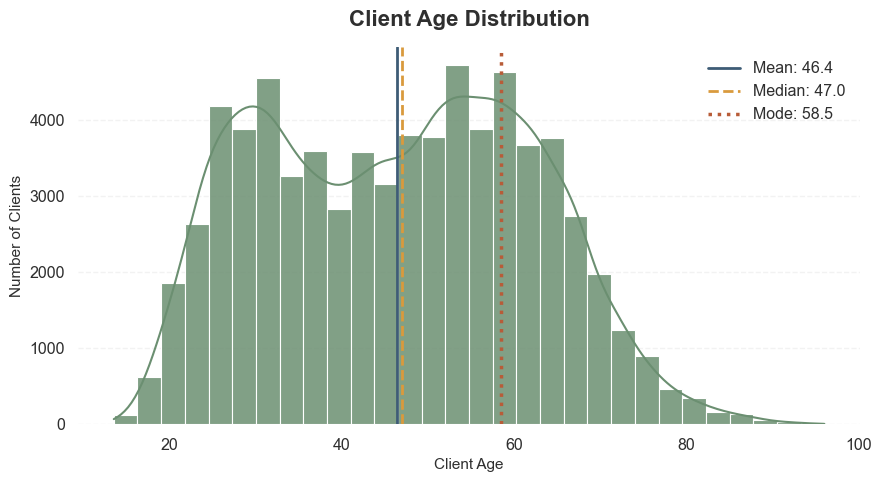

In [20]:
plt.figure(figsize=(9, 5))

ax = sns.histplot(data=df1_demo_clean,x="client_age",bins=30,kde=True,color=chart_colors["age"],edgecolor="white",linewidth=0.8,alpha=0.85)

plt.axvline(age_mean,color=project_palette["slate_blue"],linestyle="-",linewidth=2,label=f"Mean: {age_mean:.1f}")

plt.axvline(age_median,color=project_palette["amber"],linestyle="--",linewidth=2,label=f"Median: {age_median:.1f}")

plt.axvline(age_mode,color=project_palette["terracotta"],linestyle=":",linewidth=2.5,label=f"Mode: {age_mode:.1f}")

plt.title("Client Age Distribution",fontsize=16,weight="bold",pad=15)

plt.xlabel("Client Age", fontsize=11)
plt.ylabel("Number of Clients", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.legend(frameon=False)

sns.despine(left=True, bottom=True)

plt.tight_layout()

plt.savefig("../3_Visualizations/client_age_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Age Distribution Insight

The age distribution shows that Vanguard's client base is mainly concentrated among adult clients, with most observations falling between early adulthood and pre-retirement age.

The mean age is 46.4 and the median age is 47.0, which suggests that the central tendency of the distribution is fairly stable. The mode is 58.5, indicating that one of the most frequent exact age values is located within the older working-age segment.

Overall, age appears to be a useful variable for later segmentation, especially when analyzing whether different client groups behave differently during the digital process.

## 2.3 Age Group Distribution

To make the age distribution easier to interpret from a business perspective, clients are grouped into age ranges.

This grouped view helps identify which age segments represent the largest share of the client base. It also provides a clearer segmentation structure that can be reused later when comparing client behavior across the experiment groups.

In [21]:
df1_demo_clean["age_group"] = pd.cut(
    df1_demo_clean["client_age"],
    bins=[0, 17, 30, 40, 50, 60, 70, 100],
    labels=["Under 18", "18-29", "30-39", "40-49", "50-59", "60-69", "70+"],
    right=False
)

df1_demo_clean["age_group"] = df1_demo_clean["age_group"].cat.add_categories("Unknown").fillna("Unknown")

In [22]:
age_group_distribution = (df1_demo_clean["age_group"].value_counts().sort_index().reset_index())

age_group_distribution.columns = ["age_group", "client_count"]

age_group_distribution["percentage"] = (age_group_distribution["client_count"] / len(df1_demo_clean) * 100).round(2)

display(age_group_distribution)

,age_group,client_count,percentage
0,Under 18,190,0.27
1,18-29,13109,18.57
2,30-39,13132,18.60
3,40-49,12419,17.59
4,50-59,15525,21.99
5,60-69,11950,16.93
6,70+,4269,6.05
7,Unknown,1,0.00


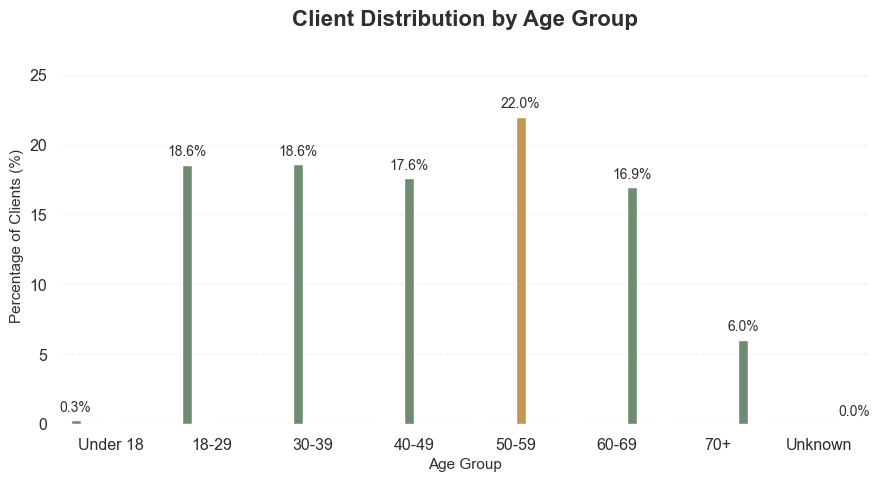

In [23]:
bar_colors = [
    project_palette["amber"] if group == "50-59" else chart_colors["age"]
    for group in age_group_distribution["age_group"].astype(str)
]

plt.figure(figsize=(9, 5))

ax = sns.barplot(data=age_group_distribution,x="age_group",y="percentage",palette=bar_colors,hue="age_group",legend=False)

plt.title("Client Distribution by Age Group",fontsize=16,weight="bold",pad=15)

plt.xlabel("Age Group", fontsize=11)
plt.ylabel("Percentage of Clients (%)", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=4, fontsize=10, color=project_palette["charcoal"])

sns.despine(left=True, bottom=True)

plt.ylim(0, age_group_distribution["percentage"].max() + 5)

plt.tight_layout()
plt.savefig("../3_Visualizations/client_age_group_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Age Group Insight

The client base is broadly distributed across adult age groups, with the strongest concentration in the `50-59` segment, which represents 22.0% of clients.

Clients between 18 and 69 account for the vast majority of the dataset, while clients under 18 and clients aged 70 or above represent much smaller shares.

This suggests that Vanguard's digital process is mainly used by adult and pre-retirement client segments. The age group variable will be useful later when comparing whether different client segments interact differently with the online process.

## 2.4 Client Tenure Distribution

Client tenure shows how long each client has been with Vanguard.

This variable is useful because long-term clients may interact differently with a redesigned digital interface compared to newer clients. Before using tenure for segmentation, we first review its overall distribution.

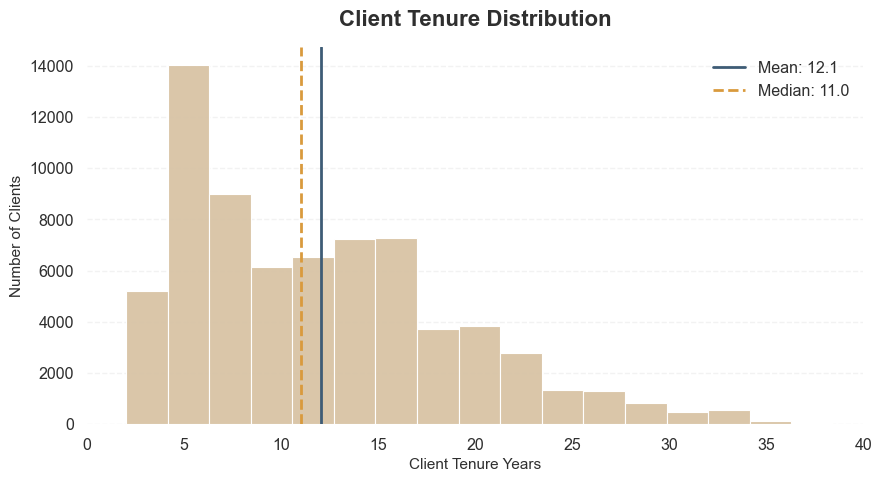

In [24]:
tenure_mean = df1_demo_clean["client_tenure_years"].mean()
tenure_median = df1_demo_clean["client_tenure_years"].median()

plt.figure(figsize=(9, 5))

ax = sns.histplot( data=df1_demo_clean, x="client_tenure_years", bins=28, color=chart_colors["tenure"], edgecolor="white", linewidth=0.8, alpha=0.95)

plt.axvline( tenure_mean, color=project_palette["slate_blue"], linestyle="-", linewidth=2, label=f"Mean: {tenure_mean:.1f}")

plt.axvline( tenure_median, color=project_palette["amber"], linestyle="--", linewidth=2, label=f"Median: {tenure_median:.1f}")

plt.title("Client Tenure Distribution", fontsize=16, weight="bold", pad=15)

plt.xlabel("Client Tenure Years", fontsize=11)
plt.ylabel("Number of Clients", fontsize=11)

plt.xlim(0, 40)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.legend(frameon=False)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("../3_Visualizations/client_tenure_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Client Tenure Distribution Insight

The tenure distribution shows that most clients have been with Vanguard for fewer than 20 years, with the highest concentration in the early tenure range.

The mean tenure is 12.1 years, while the median is 11.0 years. Since the mean is slightly higher than the median, the distribution is mildly pulled to the right by a smaller group of long-term clients.

This suggests that tenure may be useful later as a segmentation variable, especially when comparing whether newer and long-standing clients behave differently during the digital process.

## 2.5 Client Tenure Groups

To make tenure easier to compare, clients are grouped into equal-width tenure intervals.

Using equal-width groups avoids misleading comparisons between segments of different sizes. This makes the grouped tenure analysis more statistically consistent while still providing a clear business view of the client base.

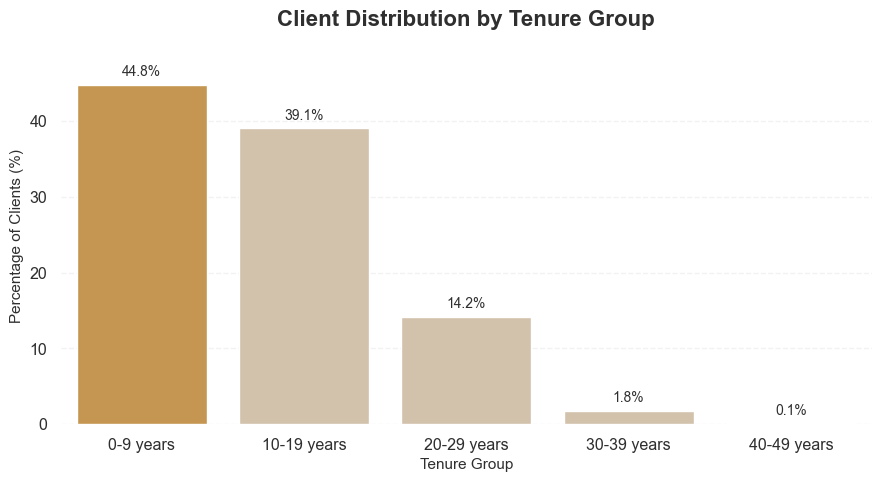

In [25]:
tenure_bins = np.arange(0, 71, 10)
tenure_labels = [f"{i}-{i+9} years" for i in tenure_bins[:-1]]

df1_demo_clean["tenure_group"] = pd.cut(df1_demo_clean["client_tenure_years"], bins=tenure_bins, labels=tenure_labels, right=False)

tenure_group_distribution = df1_demo_clean["tenure_group"].value_counts().sort_index().reset_index()
tenure_group_distribution.columns = ["tenure_group", "client_count"]
tenure_group_distribution["percentage"] = (tenure_group_distribution["client_count"] / len(df1_demo_clean) * 100).round(1)

tenure_group_distribution = tenure_group_distribution[~tenure_group_distribution["tenure_group"].isin(["50-59 years", "60-69 years"])].copy()
tenure_group_distribution["tenure_group"] = tenure_group_distribution["tenure_group"].astype(str)

highlight_group = tenure_group_distribution.loc[tenure_group_distribution["percentage"].idxmax(), "tenure_group"]
bar_colors = [project_palette["amber"] if group == highlight_group else chart_colors["tenure"] for group in tenure_group_distribution["tenure_group"]]

plt.figure(figsize=(9, 5))

ax = sns.barplot(data=tenure_group_distribution, x="tenure_group", y="percentage", hue="tenure_group", palette=bar_colors, legend=False)

plt.title("Client Distribution by Tenure Group", fontsize=16, weight="bold", pad=15)
plt.xlabel("Tenure Group", fontsize=11)
plt.ylabel("Percentage of Clients (%)", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=4, fontsize=10, color=project_palette["charcoal"])

sns.despine(left=True, bottom=True)

plt.ylim(0, tenure_group_distribution["percentage"].max() + 5)

plt.tight_layout()
plt.show()

### Tenure Group Insight

Using equal-width 10-year intervals, the tenure group distribution shows that most clients are concentrated in the first two decades of their relationship with Vanguard.

The largest segment is the `0-9 years` group, followed by the `10-19 years` group. After 20 years, the share of clients decreases sharply.

Groups above 50 years of tenure are not emphasized in the chart because they represent a negligible share of the dataset and do not provide a reliable basis for segment-level interpretation.

## 2.6 Balance Distribution

Balance is one of the main financial variables in the client profile dataset.

Since account balances vary widely between clients, a regular histogram may be misleading. A small number of high-balance clients can stretch the scale and make the majority of clients difficult to interpret.

For this reason, the balance distribution is visualized using a logarithmic scale. The log scale does not change the original balance values; it only adjusts how the x-axis is displayed.

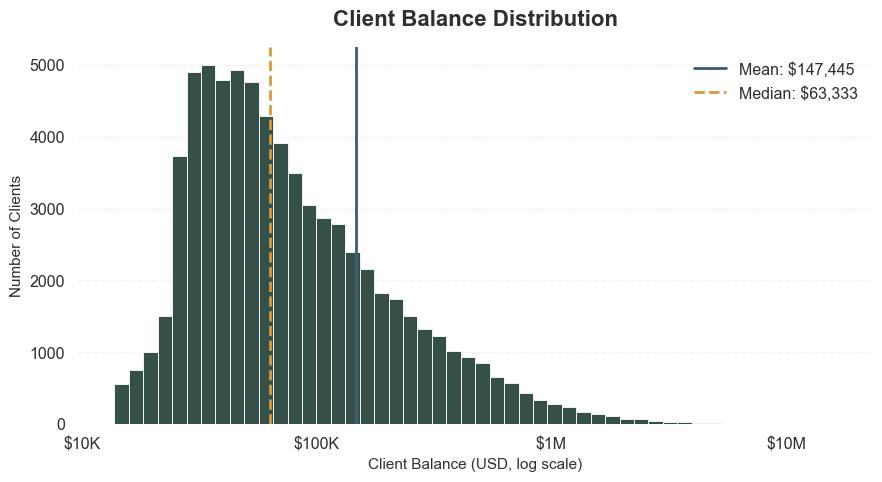

In [26]:
from matplotlib.ticker import FuncFormatter

balance_mean = df1_demo_clean["balance"].mean()
balance_median = df1_demo_clean["balance"].median()

def currency_short(x, pos):
    if x >= 1_000_000:
        return f"${x/1_000_000:.0f}M"
    if x >= 1_000:
        return f"${x/1_000:.0f}K"
    return f"${x:,.0f}"

plt.figure(figsize=(9, 5))

ax = sns.histplot(data=df1_demo_clean, x="balance", bins=50, color=chart_colors["balance"], edgecolor="white", linewidth=0.6, alpha=0.9, log_scale=(True, False))

plt.axvline(balance_mean, color=project_palette["slate_blue"], linestyle="-", linewidth=2, label=f"Mean: ${balance_mean:,.0f}")
plt.axvline(balance_median, color=project_palette["amber"], linestyle="--", linewidth=2, label=f"Median: ${balance_median:,.0f}")

plt.title("Client Balance Distribution", fontsize=16, weight="bold", pad=15)
plt.xlabel("Client Balance (USD, log scale)", fontsize=11)
plt.ylabel("Number of Clients", fontsize=11)

ax.xaxis.set_major_formatter(FuncFormatter(currency_short))

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.legend(frameon=False)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("../3_Visualizations/client_balance_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.7 Balance Percentile Summary

Since client balance is strongly right-skewed, we review key percentiles to better understand the distribution.

Percentiles provide a more robust view than the mean alone, especially when a small number of high-balance clients pull the average upward.

In [27]:
balance_percentiles = df1_demo_clean["balance"].quantile([0, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1])

balance_percentiles.index = ["Min", "25th", "Median", "75th", "90th", "95th", "99th", "Max"]

balance_percentiles_table = pd.DataFrame(balance_percentiles).T
balance_percentiles_table.index = ["Client Balance"]
balance_percentiles_table = balance_percentiles_table.map("${:,.2f}".format)

display(balance_percentiles_table)

,Min,25th,Median,75th,90th,95th,99th,Max
Client Balance,"$13,789.42","$37,346.83","$63,332.90","$137,544.90","$319,358.70","$524,823.66","$1,313,219.96","$16,320,040.15"


### Balance Distribution Insight

The balance distribution is strongly right-skewed. Most clients hold relatively moderate balances, while a smaller number of clients have substantially higher balances.

The mean balance is much higher than the median, which confirms that high-balance clients pull the average upward. For this reason, the median is a more representative measure of the typical client balance.

The percentile summary supports this interpretation by showing how quickly balances increase at the upper end of the distribution. These high-balance clients are kept in the dataset because they may represent valid financial profiles, but average-based balance comparisons should be interpreted carefully in later analysis.

## 2.8 Client Activity Overview

Client activity is measured through two variables: calls made in the last six months and logons during the same period.

Calls may reflect the need for direct support, while logons represent digital engagement with Vanguard's platform.

The chart below compares the distribution of both activity types. The x-axis represents the number of interactions in the last six months, while the y-axis shows the percentage of clients with each interaction count.

In [28]:
activity_summary = df1_demo_clean[["calls_6_months", "logons_6_months"]].describe().round(2)

display(activity_summary)

,calls_6_months,logons_6_months
count,70595.00,70595.00
mean,3.38,5.57
std,2.24,2.35
min,0.00,1.00
25%,1.00,4.00
50%,3.00,5.00
75%,6.00,7.00
max,7.00,9.00


In [29]:
calls_distribution = df1_demo_clean["calls_6_months"].value_counts().reindex(range(10), fill_value=0).sort_index().reset_index()
calls_distribution.columns = ["interaction_count", "client_count"]
calls_distribution["activity_type"] = "Calls"

logons_distribution = df1_demo_clean["logons_6_months"].value_counts().reindex(range(10), fill_value=0).sort_index().reset_index()
logons_distribution.columns = ["interaction_count", "client_count"]
logons_distribution["activity_type"] = "Logons"

activity_distribution = pd.concat([calls_distribution, logons_distribution], ignore_index=True)
activity_distribution["percentage"] = (activity_distribution["client_count"] / len(df1_demo_clean) * 100).round(1)

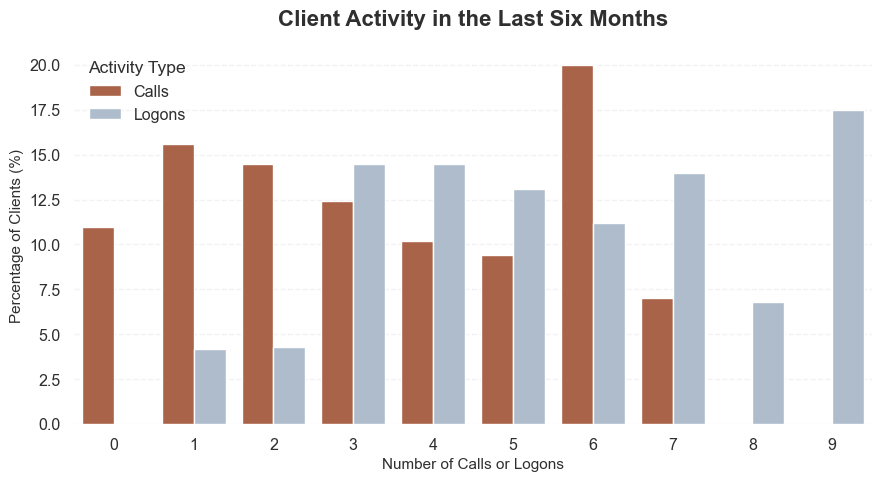

In [30]:
activity_palette = {"Calls": chart_colors["calls"], "Logons": chart_colors["activity"]}

plt.figure(figsize=(9, 5))

ax = sns.barplot(data=activity_distribution, x="interaction_count", y="percentage", hue="activity_type", palette=activity_palette)

plt.title("Client Activity in the Last Six Months", fontsize=16, weight="bold", pad=15)
plt.xlabel("Number of Calls or Logons", fontsize=11)
plt.ylabel("Percentage of Clients (%)", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.legend(title="Activity Type", frameon=False)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("../3_Visualizations/client_activity_last_six_months.png", dpi=300, bbox_inches="tight")
plt.show()

### Client Activity Insight

The activity distribution shows that clients generally logged into the platform more often than they contacted Vanguard by phone.

Calls range from 0 to 7 interactions, while logons range from 1 to 9 interactions. This suggests that digital engagement is more frequent than direct support contact across the client base.

This is relevant for the A/B test because the redesigned interface is expected to affect clients who already interact with Vanguard digitally. Later, this variable may help compare whether more digitally active clients behave differently during the online process.

## 2.9 Number of Accounts Distribution

The number of accounts provides a simple view of client profile complexity.

Clients with more accounts may have a broader relationship with Vanguard, while clients with fewer accounts may represent simpler profiles. Before using this variable in later analysis, we review its distribution across the client base.

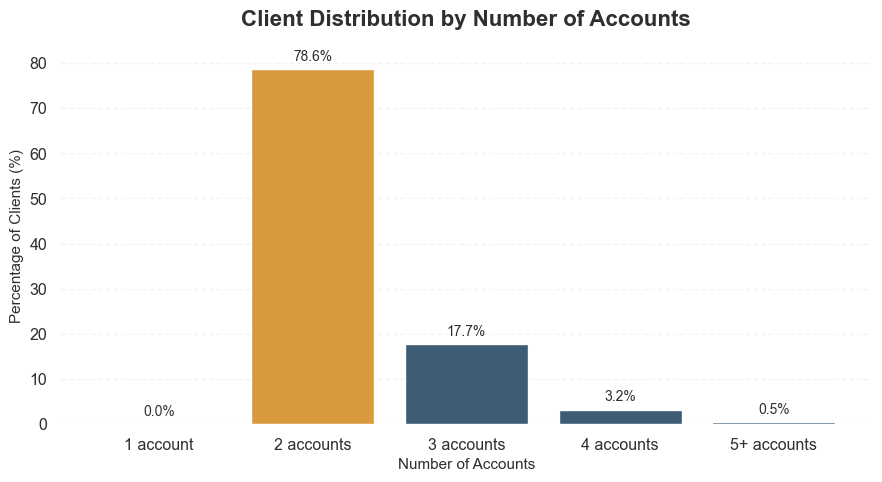

In [31]:
account_order = ["1 account", "2 accounts", "3 accounts", "4 accounts", "5+ accounts"]

df1_demo_clean["account_group"] = np.where(
    df1_demo_clean["number_accounts"] >= 5,
    "5+ accounts",
    df1_demo_clean["number_accounts"].astype(int).astype(str) + " accounts"
)

df1_demo_clean.loc[df1_demo_clean["number_accounts"] == 1, "account_group"] = "1 account"
df1_demo_clean["account_group"] = pd.Categorical(df1_demo_clean["account_group"], categories=account_order, ordered=True)

account_group_distribution = df1_demo_clean["account_group"].value_counts().reindex(account_order, fill_value=0).reset_index()
account_group_distribution.columns = ["account_group", "client_count"]
account_group_distribution["percentage"] = (account_group_distribution["client_count"] / len(df1_demo_clean) * 100).round(1)

highlight_group = account_group_distribution.loc[account_group_distribution["percentage"].idxmax(), "account_group"]
bar_colors = [project_palette["amber"] if group == highlight_group else project_palette["slate_blue"] for group in account_group_distribution["account_group"]]

plt.figure(figsize=(9, 5))

ax = plt.gca()
bars = ax.bar(account_group_distribution["account_group"], account_group_distribution["percentage"], color=bar_colors)

plt.title("Client Distribution by Number of Accounts", fontsize=16, weight="bold", pad=15)
plt.xlabel("Number of Accounts", fontsize=11)
plt.ylabel("Percentage of Clients (%)", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

ax.bar_label(bars, labels=[f"{v:.1f}%" for v in account_group_distribution["percentage"]], padding=4, fontsize=10, color=project_palette["charcoal"])

sns.despine(left=True, bottom=True)

plt.ylim(0, account_group_distribution["percentage"].max() + 5)

plt.tight_layout()
plt.savefig("../3_Visualizations/client_distribution_number_of_accounts.png", dpi=300, bbox_inches="tight")
plt.show()

### Number of Accounts Insight

Most clients hold two accounts, making this by far the most common account structure in the dataset.

Clients with five or more accounts represent a very small share of the client base, so they are grouped into a single `5+ accounts` category. This avoids misleading visual interpretation caused by very small percentages being rounded to 0.0%.

Overall, the dataset is heavily concentrated around simpler account structures, which may be useful later when comparing whether account complexity influences digital behavior.

## 2.10 Balance by Account Complexity

After reviewing the distribution of account counts, we compare client balance across broader account complexity groups.

Because the number of accounts variable is highly concentrated around two accounts, comparing every exact account count separately could lead to unstable conclusions for rare groups.

To make the comparison more reliable, clients are grouped into three broader segments: `1-2 accounts`, `3 accounts`, and `4+ accounts`.

Since balance is strongly right-skewed, the median is used as the main comparison metric instead of the mean. The interquartile range is also included to show the typical spread of balances within each group.

In [32]:
df1_demo_clean["account_complexity"] = pd.cut(
    df1_demo_clean["number_accounts"],
    bins=[0, 2, 3, np.inf],
    labels=["1-2 accounts", "3 accounts", "4+ accounts"],
    right=True
)

account_complexity_summary = df1_demo_clean.groupby("account_complexity", observed=True).agg(
    client_count=("client_id", "count"),
    client_percentage=("client_id", lambda x: round(len(x) / len(df1_demo_clean) * 100, 1)),
    q25_balance=("balance", lambda x: x.quantile(0.25)),
    median_balance=("balance", "median"),
    mean_balance=("balance", "mean"),
    q75_balance=("balance", lambda x: x.quantile(0.75))
).reset_index()

account_complexity_display = account_complexity_summary.copy()

for col in ["q25_balance", "median_balance", "mean_balance", "q75_balance"]:
    account_complexity_display[col] = account_complexity_display[col].map("${:,.0f}".format)

display(account_complexity_display)

,account_complexity,client_count,client_percentage,q25_balance,median_balance,mean_balance,q75_balance
0,1-2 accounts,55499,78.6,"$34,230","$54,446","$110,397","$108,100"
1,3 accounts,12529,17.7,"$59,786","$113,513","$248,332","$248,664"
2,4+ accounts,2567,3.6,"$116,015","$245,270","$456,022","$521,428"


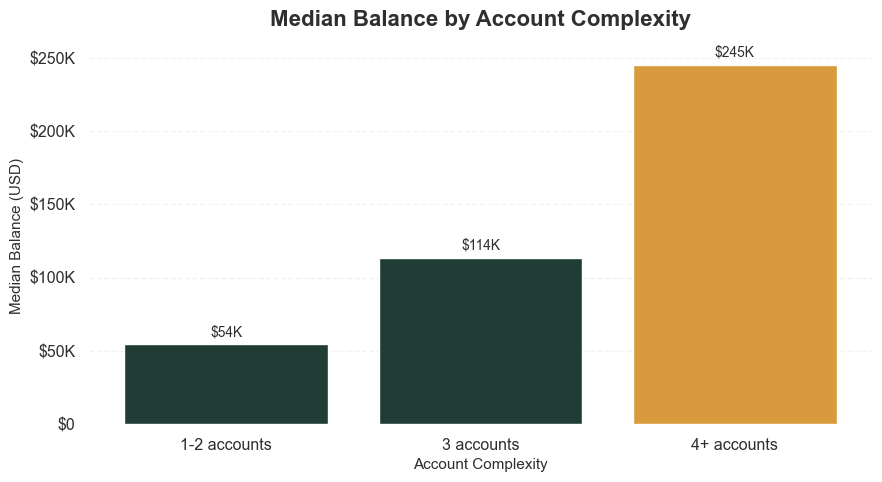

In [33]:
highlight_group = account_complexity_summary.loc[account_complexity_summary["median_balance"].idxmax(), "account_complexity"]
bar_colors = [project_palette["amber"] if group == highlight_group else chart_colors["balance"] for group in account_complexity_summary["account_complexity"].astype(str)]

plt.figure(figsize=(9, 5))

ax = plt.gca()
bars = ax.bar(
    account_complexity_summary["account_complexity"].astype(str),
    account_complexity_summary["median_balance"],
    color=bar_colors
)

plt.title("Median Balance by Account Complexity", fontsize=16, weight="bold", pad=15)
plt.xlabel("Account Complexity", fontsize=11)
plt.ylabel("Median Balance (USD)", fontsize=11)

ax.yaxis.set_major_formatter(FuncFormatter(currency_short))
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

ax.bar_label(
    bars,
    labels=[f"${v/1000:.0f}K" for v in account_complexity_summary["median_balance"]],
    padding=4,
    fontsize=10,
    color=project_palette["charcoal"]
)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("../3_Visualizations/median_balance_by_account.png", dpi=300, bbox_inches="tight")
plt.show()

### Balance by Account Complexity Insight

Clients with more complex account structures tend to hold higher median balances.

Because balance is strongly right-skewed, the median is used as the main comparison metric. Additional summary statistics such as the 25th and 75th percentiles are provided in the table to show the spread within each group.

This approach is more reliable than comparing exact account counts separately, since the dataset is heavily concentrated around simpler account structures.

## 2.11 Balance by Age Group

To understand the economic importance of different client age groups, we analyze total and typical client balance by age segment.

Total balance helps identify which age groups represent the largest amount of assets for the company.

Median balance is also included because balance is usually highly skewed, meaning that a few very wealthy clients can strongly affect the mean.

In [34]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

input_path = Path("../1.1_Clean_files/")

df1_demo_clean = pd.read_csv(input_path / "df1_demo_clean.csv")

In [35]:
age_bins = [0, 17, 30, 40, 50, 60, 70, np.inf]
age_labels = ["<18", "18-30", "31-40", "41-50", "51-60", "61-70", "+70"]

df1_demo_clean["age_group"] = pd.cut(
    df1_demo_clean["client_age"],
    bins=age_bins,
    labels=age_labels,
    right=True,
    include_lowest=True
)

print(df1_demo_clean["age_group"].value_counts(dropna=False).sort_index())

age_group
<18        251
18-30    13773
31-40    12930
41-50    12590
51-60    15549
61-70    11571
+70       3930
NaN          1
Name: count, dtype: int64


In [36]:
age_balance_summary = (
    df1_demo_clean
    .groupby("age_group", observed=False)
    .agg(
        clients=("client_id", "count"),
        total_balance=("balance", "sum"),
        mean_balance=("balance", "mean"),
        median_balance=("balance", "median")
    )
    .reset_index()
)

age_balance_summary["client_share"] = age_balance_summary["clients"] / age_balance_summary["clients"].sum()
age_balance_summary["balance_share"] = age_balance_summary["total_balance"] / age_balance_summary["total_balance"].sum()
age_balance_summary["total_balance_millions"] = age_balance_summary["total_balance"] / 1_000_000

age_balance_summary

,age_group,clients,total_balance,mean_balance,median_balance,client_share,balance_share,total_balance_millions
0,<18,251,8.555939e+06,34087.405538,24697.580,0.003556,0.000822,8.555939
1,18-30,13773,8.409829e+08,61060.256716,42377.980,0.195102,0.080795,840.982916
2,31-40,12930,1.275852e+09,98673.791860,56556.130,0.183160,0.122574,1275.852129
3,41-50,12590,1.786262e+09,141879.419438,67322.480,0.178344,0.171610,1786.261891
4,51-60,15549,2.836305e+09,182410.785152,79239.290,0.220260,0.272490,2836.305298
5,61-70,11571,2.684601e+09,232011.136158,103525.450,0.163909,0.257915,2684.600856
6,+70,3930,9.762952e+08,248421.166333,119478.565,0.055670,0.093795,976.295184


In [37]:
age_balance_summary_display = age_balance_summary[
    ["age_group", "clients", "total_balance_millions", "mean_balance", "median_balance", "client_share", "balance_share"]
].copy()

age_balance_summary_display["total_balance_millions"] = age_balance_summary_display["total_balance_millions"].round(2)
age_balance_summary_display["mean_balance"] = age_balance_summary_display["mean_balance"].round(2)
age_balance_summary_display["median_balance"] = age_balance_summary_display["median_balance"].round(2)
age_balance_summary_display["client_share"] = (age_balance_summary_display["client_share"] * 100).round(2)
age_balance_summary_display["balance_share"] = (age_balance_summary_display["balance_share"] * 100).round(2)

age_balance_summary_display = age_balance_summary_display.rename(columns={
    "age_group": "Age Group",
    "clients": "Clients",
    "total_balance_millions": "Total Balance ($M)",
    "mean_balance": "Mean Balance ($)",
    "median_balance": "Median Balance ($)",
    "client_share": "Client Share (%)",
    "balance_share": "Balance Share (%)"
})

age_balance_summary_display

,Age Group,Clients,Total Balance ($M),Mean Balance ($),Median Balance ($),Client Share (%),Balance Share (%)
0,<18,251,8.56,34087.41,24697.58,0.36,0.08
1,18-30,13773,840.98,61060.26,42377.98,19.51,8.08
2,31-40,12930,1275.85,98673.79,56556.13,18.32,12.26
3,41-50,12590,1786.26,141879.42,67322.48,17.83,17.16
4,51-60,15549,2836.31,182410.79,79239.29,22.03,27.25
5,61-70,11571,2684.60,232011.14,103525.45,16.39,25.79
6,+70,3930,976.30,248421.17,119478.56,5.57,9.38


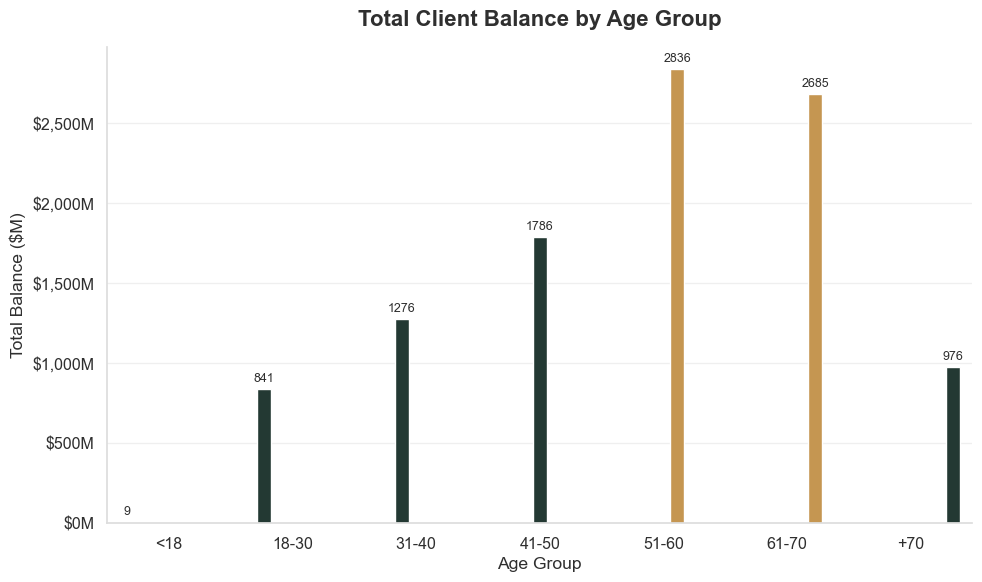

In [38]:
colors = [
    chart_colors["highlight"] if group in ["51-60", "61-70"] else chart_colors["balance"]
    for group in age_labels
]

palette_dict = dict(zip(age_labels, colors))

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=age_balance_summary,
    x="age_group",
    y="total_balance_millions",
    order=age_labels,
    hue="age_group",
    palette=palette_dict,
    legend=False
)

plt.title("Total Client Balance by Age Group", fontsize=16, weight="bold", pad=15)
plt.xlabel("Age Group")
plt.ylabel("Total Balance ($M)")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}M"))

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)

plt.grid(axis="y", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

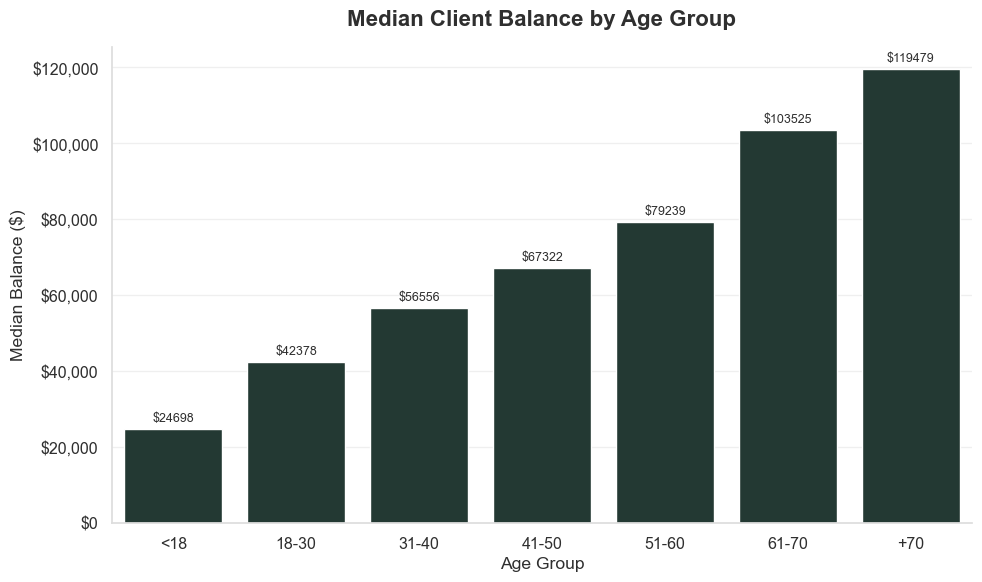

In [39]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=age_balance_summary,
    x="age_group",
    y="median_balance",
    order=age_labels,
    color=chart_colors["balance"]
)

plt.title("Median Client Balance by Age Group", fontsize=16, weight="bold", pad=15)
plt.xlabel("Age Group")
plt.ylabel("Median Balance ($)")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}"))

for container in ax.containers:
    ax.bar_label(container, fmt="$%.0f", padding=3, fontsize=9)

plt.grid(axis="y", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

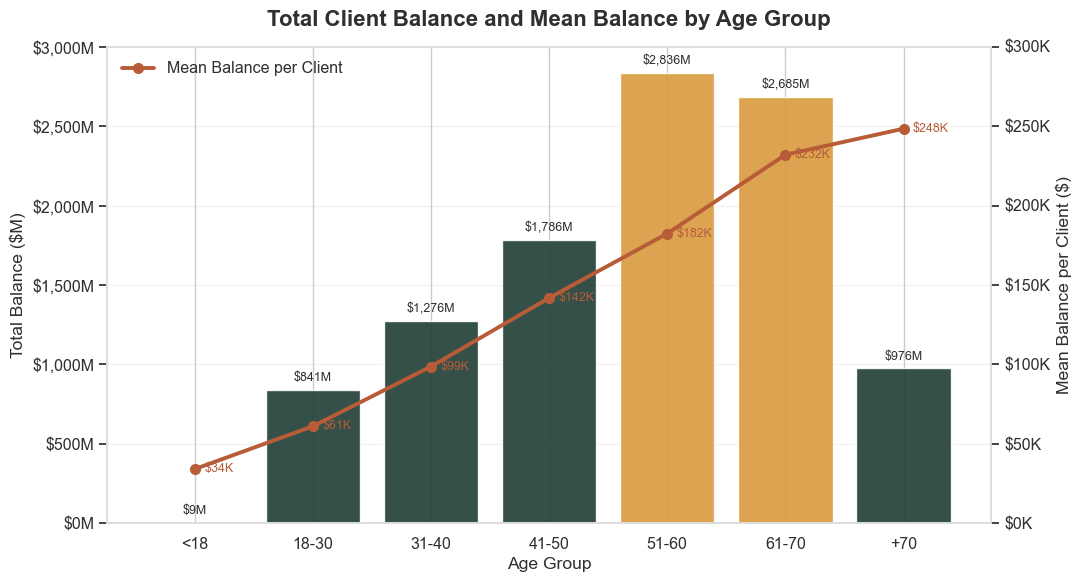

In [40]:
plot_df = age_balance_summary.copy()
x = np.arange(len(plot_df))

bar_colors = [
    chart_colors["highlight"] if group in ["51-60", "61-70"] else chart_colors["balance"]
    for group in plot_df["age_group"]
]

fig, ax1 = plt.subplots(figsize=(11, 6))

bars = ax1.bar(x, plot_df["total_balance_millions"], color=bar_colors, alpha=0.9)

ax1.set_title("Total Client Balance and Mean Balance by Age Group", fontsize=16, weight="bold", pad=15)
ax1.set_xlabel("Age Group")
ax1.set_ylabel("Total Balance ($M)")
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["age_group"])

ax1.set_ylim(0, 3000)
ax1.set_yticks(np.arange(0, 3001, 500))
ax1.yaxis.set_major_formatter(FuncFormatter(lambda value, pos: f"${value:,.0f}M"))

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 35, f"${height:,.0f}M", ha="center", va="bottom", fontsize=9, color=project_palette["charcoal"])

ax2 = ax1.twinx()

ax2.plot(
    x,
    plot_df["mean_balance"],
    color=project_palette["terracotta"],
    marker="o",
    markersize=7,
    linewidth=2.8,
    label="Mean Balance per Client"
)

ax2.set_ylabel("Mean Balance per Client ($)")
ax2.set_ylim(0, 300000)
ax2.set_yticks(np.arange(0, 300001, 50000))
ax2.yaxis.set_major_formatter(FuncFormatter(lambda value, pos: f"${value/1_000:.0f}K"))

for i, value in enumerate(plot_df["mean_balance"]):
    ax2.text(i + 0.08, value, f"${value/1_000:.0f}K", color=project_palette["terracotta"], va="center", fontsize=9)

ax1.grid(axis="y", alpha=0.25)
ax2.grid(False)

ax2.legend(loc="upper left", frameon=False)

sns.despine(ax=ax1, right=False)
plt.tight_layout()
plt.show()

In [ ]:
#Checking consistency of age groups that completed survey between test and control groups

In [60]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from pathlib import Path

pD = Path("..") / "1.2_Merged_Files_For_EDA" / "session_big_df.csv"
dfD = pd.read_csv(pD, sep=",", encoding="utf-8", engine="python")

dfD['incomplete_flag'] = dfD['incomplete_flag'].astype(str).str.strip().str.lower().map({
    'true': True, 'false': False, '1': True, '0': False, 't': True, 'f': False
})
dfD = dfD[dfD['incomplete_flag'] == False]
dfD = dfD.drop_duplicates(subset=['client_id'])

dfD['variation'] = dfD['variation'].astype(str).fillna('').str.strip().str.lower()
mapping = {}
for v in dfD['variation'].unique():
    if v in ('test','t','experiment','var_test','variant_test'):
        mapping[v] = 'test'
    elif v in ('control','c','baseline','var_control','variant_control'):
        mapping[v] = 'control'
    else:
        mapping[v] = v
dfD['variation'] = dfD['variation'].map(mapping)

variants = set([v for v in dfD['variation'].unique() if v not in ('', 'nan', 'none', None)])
if not {'test','control'}.issubset(variants):
    raise ValueError(f"After mapping, expected 'test' and 'control'. Found: {sorted(list(variants))}")

bins = [0, 17, 29, 39, 49, 59, 69, 200]
labels = ['under 18', '18-29', '30-39', '40-49', '50-59', '60-69', '70+']
dfD['client_age'] = pd.to_numeric(dfD['client_age'], errors='coerce')
dfD['age_group'] = pd.cut(dfD['client_age'], bins=bins, labels=labels, right=True)
dfD['age_group'] = pd.Categorical(dfD['age_group'], categories=labels, ordered=True)

variant_totals = dfD.groupby('variation')['client_id'].nunique().to_dict()
total_test = int(variant_totals.get('test', 0))
total_control = int(variant_totals.get('control', 0))

counts = dfD.groupby(['age_group', 'variation'])['client_id'].nunique().unstack(fill_value=0)
for col in ['test', 'control']:
    if col not in counts.columns:
        counts[col] = 0
counts = counts.reindex(labels).fillna(0)[['test','control']]

results = []
alpha = 0.05
for ag in labels:
    count_test_age = int(counts.loc[ag, 'test'])
    count_control_age = int(counts.loc[ag, 'control'])
    test_pct = (count_test_age / total_test * 100) if total_test > 0 else np.nan
    control_pct = (count_control_age / total_control * 100) if total_control > 0 else np.nan
    if total_test == 0 or total_control == 0:
        p_value = np.nan
        consistency = 'insufficient'
    else:
        counts_array = np.array([count_test_age, count_control_age])
        nobs = np.array([total_test, total_control])
        try:
            stat, p_value = proportions_ztest(counts_array, nobs)
            consistency = 'yes' if p_value > alpha else 'no'
        except Exception:
            p_value = np.nan
            consistency = 'error'
    results.append({
        'age_group': ag,
        'test_count_in_age': count_test_age,
        'control_count_in_age': count_control_age,
        'test_pct_of_variant (%)': round(test_pct, 4) if not np.isnan(test_pct) else np.nan,
        'control_pct_of_variant (%)': round(control_pct, 4) if not np.isnan(control_pct) else np.nan,
        'p_value': p_value,
        'Consistency': consistency
    })

out_df = pd.DataFrame(results)
display(out_df)

,age_group,test_count_in_age,control_count_in_age,test_pct_of_variant (%),control_pct_of_variant (%),p_value,Consistency
0,under 18,1,2,0.0054,0.0130,0.455722,yes
1,18-29,3061,2438,16.3804,15.7963,0.144156,yes
2,30-39,3799,2989,20.3296,19.3663,0.026517,no
3,40-49,3184,2712,17.0386,17.5716,0.194918,yes
4,50-59,3977,3439,21.2822,22.2820,0.025834,no
5,60-69,3499,2900,18.7242,18.7897,0.877508,yes
6,70+,1161,948,6.2129,6.1423,0.787534,yes


In [ ]:
#Summary of results

# Most age groups (under 18, 18–29, 40–49, 60–69, 70+) show no statistically significant difference in share between Test and Control (p > 0.05 → "Consistency = yes").
# Two groups show significant differences: 30–39 (Test share ≈ 20.33% vs Control ≈ 19.37%, p≈0.0265 → Test higher) and 50–59 (Test ≈21.28% vs Control ≈22.28%, p≈0.0258 → Control higher).
# What the table means

# test_count_in_age / control_count_in_age: number of unique clients in that age bin for each variant.
# test_pct_of_variant (%) / control_pct_of_variant (%): proportion of the variant’s total users that fall into the age bin (e.g., 20% = 20% of Test users).
# p_value: result of two-proportion z-test comparing the two proportions.
# Consistency = "yes" means the difference is not statistically significant at α=0.05; "no" means significant.
# Practical interpretation

# Although two bins are statistically different, the absolute differences are small (~0.96–1.00 percentage points). With large sample sizes even small differences can be statistically significant; assess whether a ~1 p.p. difference matters operationally.
# For groups labeled "yes" you can treat Test vs Control as balanced by age; for the two "no" groups age imbalance exists and could confound metrics unless controlled.

### Interpretation

The chart combines two complementary perspectives on client value by age group.

The bars show total balance, which indicates the overall asset importance of each age segment for Vanguard. The line shows average balance per client, which helps compare the financial value of a client across age groups.

The 51-60 and 61-70 age groups hold the largest total balance, making them especially important from an asset perspective.

At the same time, average balance per client increases steadily with age. This suggests that older clients tend to hold larger balances individually.

However, average balance should be interpreted carefully because balance is usually skewed and can be influenced by very high-value clients. For that reason, the average is useful to understand economic weight, but it may not fully represent the typical client in each age group.

This is relevant for the project because if older age groups experience higher friction in the digital process, the business impact may be greater due to the value they represent.

## 2.12 Client Profile EDA Summary

The exploratory analysis of the client profile dataset provides a first understanding of Vanguard's client base before evaluating the A/B test.

The main findings are:

- Gender is relatively balanced between male and female clients, although the `Unknown` category represents a substantial share of the dataset.
- The client base is mainly concentrated among adult clients, with the `50-59` age group being the largest segment.
- Most clients have been with Vanguard for fewer than 20 years, with tenure concentrated in the first two decades.
- Client balance is strongly right-skewed, meaning that a smaller number of high-balance clients pull the average upward.
- Total balance is highest among the `51-60` and `61-70` age groups, making these segments especially important from an asset perspective.
- Average balance per client increases steadily with age, suggesting that older clients tend to hold larger balances individually. However, this average should be interpreted carefully because balance is affected by high-value outliers.
- Clients generally log into the platform more often than they contact Vanguard by phone.
- Most clients hold two accounts, suggesting that the majority of profiles have a relatively simple account structure.
- Clients with more accounts tend to show higher median balances, although rare account-count groups need to be interpreted carefully.

Overall, this dataset is now ready to be used as a client profile layer in the wider A/B test analysis. The next step will be to merge it with the experiment roster and digital footprint datasets.

# 3. Export Final Client Profile Dataset

After cleaning the dataset and creating useful segmentation variables, the final client profile dataset is exported.

This file will be used later to enrich the experiment analysis with demographic, financial, and behavioral client attributes.

In [41]:
output_path = "../1.1_Clean_Files/df1_demo_clean.csv"

df1_demo_clean.to_csv(output_path, index=False)

print(f"Final client profile dataset saved to: {output_path}")
print(f"Final shape: {df1_demo_clean.shape}")

Final client profile dataset saved to: ../1.1_Clean_Files/df1_demo_clean.csv
Final shape: (70595, 10)


In [42]:
final_check = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "duplicated_client_ids",
        "missing_values_total"
    ],
    "value": [
        df1_demo_clean.shape[0],
        df1_demo_clean.shape[1],
        df1_demo_clean["client_id"].duplicated().sum(),
        df1_demo_clean.isna().sum().sum()
    ]
})

display(final_check)

,metric,value
0,rows,70595
1,columns,10
2,duplicated_client_ids,0
3,missing_values_total,2


# Understanding the data


In [43]:
''' KPIS:
1) Completion Rate test Vs control 
completed by id / total started by id
2) average time of iteration test vs control 
average (total time by user id/ total steps by user id)
3) Error Rate = number of errors / number of sessions or attempts
4) Step Completion Rate = clients who reached next step / clients who reached current step
5) Average number of step visits per client
average(total steps by client_id)
6)  Median Time per Step test vs control
    Average Time per Step
    Total Completion Time
    Higher completion rate + lower or similar time spent
7)Backtracking Rate = clients who move backwards / clients who started
8)Drop-off Rate = clients who abandon at step / clients who reached that step

9) Client Segment Performance:
Age group
Gender
Tenure
Balance group
Number of accounts
Calls/logons activity '''

' KPIS:\n1) Completion Rate test Vs control \ncompleted by id / total started by id\n2) average time of iteration test vs control \naverage (total time by user id/ total steps by user id)\n3) Error Rate = number of errors / number of sessions or attempts\n4) Step Completion Rate = clients who reached next step / clients who reached current step\n5) Average number of step visits per client\naverage(total steps by client_id)\n6)  Median Time per Step test vs control\n    Average Time per Step\n    Total Completion Time\n    Higher completion rate + lower or similar time spent\n7)Backtracking Rate = clients who move backwards / clients who started\n8)Drop-off Rate = clients who abandon at step / clients who reached that step\n\n9) Client Segment Performance:\nAge group\nGender\nTenure\nBalance group\nNumber of accounts\nCalls/logons activity '

In [44]:
import pandas as pd
import numpy as np

# =========================
# 0. Load data
# =========================

demo_path = "../1.1_Clean_Files/df1_demo_clean_plus_experiments_clients.csv"
web_path = "../1.1_Clean_Files/final_web_data_plus_experiments_clients.csv"

df_demo = pd.read_csv(demo_path)
df_web = pd.read_csv(web_path)

step_order = ["start", "step_1", "step_2", "step_3", "confirm"]
step_rank = {step: i for i, step in enumerate(step_order)}
valid_variations = ["Control", "Test"]

# =========================
# 1. Clean web data
# =========================

df_web = df_web.copy()

df_web["Variation"] = df_web["Variation"].astype(str).str.strip().str.title()
df_web["process_step"] = df_web["process_step"].astype(str).str.strip().str.lower()
df_web["date_time"] = pd.to_datetime(df_web["date_time"], errors="coerce")

df_web = df_web[
    df_web["Variation"].isin(valid_variations) &
    df_web["process_step"].isin(step_order) &
    df_web["date_time"].notna()
].copy()

df_web["step_order"] = df_web["process_step"].map(step_rank)
df_web["session_id"] = df_web["Variation"] + "__" + df_web["visit_id"].astype(str)

df_web = df_web.sort_values(["Variation", "client_id", "visit_id", "date_time"]).reset_index(drop=True)

In [45]:
# Previous / next step inside each session

df_web["prev_step_order"] = df_web.groupby("session_id")["step_order"].shift(1)
df_web["next_step_order"] = df_web.groupby("session_id")["step_order"].shift(-1)
df_web["next_date_time"] = df_web.groupby("session_id")["date_time"].shift(-1)

df_web["time_to_next_sec"] = (df_web["next_date_time"] - df_web["date_time"]).dt.total_seconds()
df_web.loc[df_web["time_to_next_sec"] < 0, "time_to_next_sec"] = np.nan
df_web["time_to_next_min"] = df_web["time_to_next_sec"] / 60

df_web["is_backtrack_event"] = df_web["step_order"] < df_web["prev_step_order"]
df_web["is_repeat_step_event"] = df_web["step_order"] == df_web["prev_step_order"]

# Error proxy: repeated step or backward movement
df_web["is_error_event"] = df_web["is_backtrack_event"] | df_web["is_repeat_step_event"]

In [46]:
session_cols = ["Variation", "client_id", "visit_id", "session_id"]

session_summary = (
    df_web.groupby(session_cols)
    .agg(
        first_time=("date_time", "min"),
        last_time=("date_time", "max"),
        first_step=("process_step", "first"),
        last_step=("process_step", "last"),
        n_step_visits=("process_step", "size"),
        n_unique_steps=("process_step", "nunique"),
        started=("process_step", lambda x: (x == "start").any()),
        completed=("process_step", lambda x: (x == "confirm").any()),
        backtracked=("is_backtrack_event", "any"),
        had_error=("is_error_event", "any"),
        error_events=("is_error_event", "sum")
    )
    .reset_index()
)

session_summary["session_duration_min"] = (
    session_summary["last_time"] - session_summary["first_time"]
).dt.total_seconds() / 60

first_start = df_web[df_web["process_step"].eq("start")].groupby("session_id")["date_time"].min()
first_confirm = df_web[df_web["process_step"].eq("confirm")].groupby("session_id")["date_time"].min()

session_summary["first_start_time"] = session_summary["session_id"].map(first_start)
session_summary["first_confirm_time"] = session_summary["session_id"].map(first_confirm)

session_summary["completion_time_min"] = (
    session_summary["first_confirm_time"] - session_summary["first_start_time"]
).dt.total_seconds() / 60

session_summary.loc[session_summary["completion_time_min"] < 0, "completion_time_min"] = np.nan

In [47]:
overall = (
    session_summary.groupby("Variation")
    .agg(
        clients=("client_id", "nunique"),
        sessions=("session_id", "nunique"),
        started_sessions=("started", "sum"),
        completed_sessions=("completed", "sum"),
        sessions_with_errors=("had_error", "sum"),
        error_events=("error_events", "sum"),
        sessions_with_backtracking=("backtracked", "sum"),
        avg_iteration_time_min=("session_duration_min", "mean"),
        median_iteration_time_min=("session_duration_min", "median"),
        avg_step_visits_per_session=("n_step_visits", "mean"),
        median_step_visits_per_session=("n_step_visits", "median"),
        avg_completion_time_min=("completion_time_min", "mean"),
        median_completion_time_min=("completion_time_min", "median")
    )
    .reset_index()
)

overall["completion_rate"] = overall["completed_sessions"] / overall["started_sessions"]
overall["error_rate_sessions"] = overall["sessions_with_errors"] / overall["started_sessions"]
overall["error_events_per_session"] = overall["error_events"] / overall["started_sessions"]
overall["backtracking_rate"] = overall["sessions_with_backtracking"] / overall["started_sessions"]

client_step_visits = (
    df_web.groupby(["Variation", "client_id"])
    .agg(total_step_visits=("process_step", "size"))
    .reset_index()
    .groupby("Variation")
    .agg(
        avg_step_visits_per_client=("total_step_visits", "mean"),
        median_step_visits_per_client=("total_step_visits", "median")
    )
    .reset_index()
)

overall = overall.merge(client_step_visits, on="Variation", how="left")

kpi_cols = [
    "clients",
    "sessions",
    "started_sessions",
    "completed_sessions",
    "completion_rate",
    "avg_iteration_time_min",
    "median_iteration_time_min",
    "error_rate_sessions",
    "error_events_per_session",
    "avg_step_visits_per_client",
    "median_step_visits_per_client",
    "avg_completion_time_min",
    "median_completion_time_min",
    "backtracking_rate"
]

kpi_overview = (
    overall.melt(id_vars="Variation", value_vars=kpi_cols, var_name="kpi", value_name="value")
    .pivot(index="kpi", columns="Variation", values="value")
    .reset_index()
)

kpi_overview["test_minus_control"] = kpi_overview["Test"] - kpi_overview["Control"]
kpi_overview["lift_%"] = np.where(
    kpi_overview["Control"].ne(0),
    (kpi_overview["test_minus_control"] / kpi_overview["Control"]) * 100,
    np.nan
)

kpi_overview.round(4)

Variation,kpi,Control,Test,test_minus_control,lift_%
0,avg_completion_time_min,6.5352,6.2704,-0.2648,-4.0514
1,avg_iteration_time_min,4.6752,5.2576,0.5824,12.4578
2,avg_step_visits_per_client,5.9721,6.5522,0.5800,9.7126
3,backtracking_rate,0.2121,0.3016,0.0895,42.1926
4,clients,23532.0000,26968.0000,3436.0000,14.6014
5,completed_sessions,16088.0000,21791.0000,5703.0000,35.4488
6,completion_rate,0.5196,0.6560,0.1364,26.2460
7,error_events_per_session,0.7528,1.0631,0.3103,41.2181
8,error_rate_sessions,0.3897,0.5044,0.1146,29.4159
9,median_completion_time_min,4.5333,3.9667,-0.5667,-12.5000


In [48]:
time_per_step = (
    df_web.dropna(subset=["time_to_next_min"])
    .groupby(["Variation", "process_step"])
    .agg(
        step_events=("time_to_next_min", "count"),
        avg_time_per_step_min=("time_to_next_min", "mean"),
        median_time_per_step_min=("time_to_next_min", "median")
    )
    .reset_index()
)

time_per_step_summary = (
    time_per_step.melt(
        id_vars=["Variation", "process_step"],
        value_vars=[
            "step_events",
            "avg_time_per_step_min",
            "median_time_per_step_min"
        ],
        var_name="kpi",
        value_name="value"
    )
    .pivot(index=["process_step", "kpi"], columns="Variation", values="value")
    .reset_index()
)

time_per_step_summary["test_minus_control"] = time_per_step_summary["Test"] - time_per_step_summary["Control"]
time_per_step_summary["lift_%"] = np.where(
    time_per_step_summary["Control"].ne(0),
    (time_per_step_summary["test_minus_control"] / time_per_step_summary["Control"]) * 100,
    np.nan
)

time_per_step_summary.round(4)

Variation,process_step,kpi,Control,Test,test_minus_control,lift_%
0,confirm,avg_time_per_step_min,2.8661,4.0780,1.2119,42.2855
1,confirm,median_time_per_step_min,0.7833,1.5500,0.7667,97.8723
2,confirm,step_events,1952.0000,4119.0000,2167.0000,111.0143
3,start,avg_time_per_step_min,1.1138,1.0245,-0.0893,-8.0134
4,start,median_time_per_step_min,0.3333,0.2333,-0.1000,-30.0000
5,start,step_events,35738.0000,46323.0000,10585.0000,29.6183
6,step_1,avg_time_per_step_min,0.8412,1.0113,0.1701,20.2166
7,step_1,median_time_per_step_min,0.3333,0.4500,0.1167,35.0000
8,step_1,step_events,26044.0000,35527.0000,9483.0000,36.4115
9,step_2,avg_time_per_step_min,1.5334,1.4808,-0.0526,-3.4298


In [49]:
def mode_or_nan(x):
    x = x.dropna()
    return x.mode().iloc[0] if not x.mode().empty else np.nan

df_demo = df_demo.copy()
df_demo["Variation"] = df_demo["Variation"].astype(str).str.strip().str.title()
df_demo = df_demo[df_demo["Variation"].isin(valid_variations)].copy()

duplicate_clients = df_demo.duplicated("client_id").sum()

if duplicate_clients > 0:
    print(f"WARNING: df_demo has {duplicate_clients:,} duplicated client_id rows. Segment KPIs may be unreliable unless you use one clean row per client.")

demo_clients = (
    df_demo.groupby("client_id")
    .agg(
        demo_variation=("Variation", mode_or_nan),
        client_age=("client_age", "median"),
        gender=("gender", mode_or_nan),
        client_tenure_years=("client_tenure_years", "median"),
        client_tenure_months=("client_tenure_months", "median"),
        balance=("balance", "median"),
        number_accounts=("number_accounts", "median"),
        calls_6_months=("calls_6_months", "median"),
        logons_6_months=("logons_6_months", "median")
    )
    .reset_index()
)

client_perf = (
    session_summary.groupby(["Variation", "client_id"])
    .agg(
        sessions=("session_id", "nunique"),
        started_sessions=("started", "sum"),
        completed_sessions=("completed", "sum"),
        sessions_with_errors=("had_error", "sum"),
        sessions_with_backtracking=("backtracked", "sum"),
        avg_iteration_time_min=("session_duration_min", "mean"),
        median_completion_time_min=("completion_time_min", "median"),
        avg_step_visits_per_session=("n_step_visits", "mean")
    )
    .reset_index()
)

client_perf = client_perf.merge(
    demo_clients.drop(columns="demo_variation"),
    on="client_id",
    how="left"
)

client_perf["age_group"] = pd.cut(client_perf["client_age"], bins=[0, 30, 40, 50, 60, 70, np.inf], labels=["<30", "30-39", "40-49", "50-59", "60-69", "70+"])
client_perf["tenure_group"] = pd.cut(client_perf["client_tenure_years"], bins=[-1, 5, 10, 20, np.inf], labels=["0-5y", "6-10y", "11-20y", "20y+"])
client_perf["balance_group"] = pd.qcut(client_perf["balance"], q=4, labels=["low_balance", "mid_low_balance", "mid_high_balance", "high_balance"], duplicates="drop")
client_perf["accounts_group"] = pd.cut(client_perf["number_accounts"], bins=[0, 2, 3, np.inf], labels=["1-2 accounts", "3 accounts", "4+ accounts"])
client_perf["calls_group"] = pd.cut(client_perf["calls_6_months"], bins=[-1, 0, 3, 6, np.inf], labels=["0 calls", "1-3 calls", "4-6 calls", "7+ calls"])
client_perf["logons_group"] = pd.cut(client_perf["logons_6_months"], bins=[-1, 3, 6, 9, np.inf], labels=["0-3 logons", "4-6 logons", "7-9 logons", "10+ logons"])

segment_cols = [
    "age_group",
    "gender",
    "tenure_group",
    "balance_group",
    "accounts_group",
    "calls_group",
    "logons_group"
]

segment_tables = []

for segment_col in segment_cols:
    seg = (
        client_perf.dropna(subset=[segment_col])
        .groupby(["Variation", segment_col], observed=True)
        .agg(
            clients=("client_id", "nunique"),
            sessions=("sessions", "sum"),
            started_sessions=("started_sessions", "sum"),
            completed_sessions=("completed_sessions", "sum"),
            sessions_with_errors=("sessions_with_errors", "sum"),
            sessions_with_backtracking=("sessions_with_backtracking", "sum"),
            avg_iteration_time_min=("avg_iteration_time_min", "mean"),
            median_completion_time_min=("median_completion_time_min", "median"),
            avg_step_visits_per_session=("avg_step_visits_per_session", "mean")
        )
        .reset_index()
        .rename(columns={segment_col: "segment_value"})
    )

    seg["segment_type"] = segment_col
    seg["completion_rate"] = seg["completed_sessions"] / seg["started_sessions"]
    seg["error_rate_sessions"] = seg["sessions_with_errors"] / seg["started_sessions"]
    seg["backtracking_rate"] = seg["sessions_with_backtracking"] / seg["started_sessions"]

    segment_tables.append(seg)

segment_performance = pd.concat(segment_tables, ignore_index=True)

segment_summary = (
    segment_performance.melt(
        id_vars=["segment_type", "segment_value", "Variation"],
        value_vars=[
            "clients",
            "sessions",
            "completion_rate",
            "avg_iteration_time_min",
            "median_completion_time_min",
            "error_rate_sessions",
            "backtracking_rate",
            "avg_step_visits_per_session"
        ],
        var_name="kpi",
        value_name="value"
    )
    .pivot(index=["segment_type", "segment_value", "kpi"], columns="Variation", values="value")
    .reset_index()
)

segment_summary["test_minus_control"] = segment_summary["Test"] - segment_summary["Control"]
segment_summary["lift_%"] = np.where(
    segment_summary["Control"].ne(0),
    (segment_summary["test_minus_control"] / segment_summary["Control"]) * 100,
    np.nan
)

segment_summary.round(4)

Variation,segment_type,segment_value,kpi,Control,Test,test_minus_control,lift_%
0,accounts_group,1-2 accounts,avg_iteration_time_min,5.0065,5.5655,0.5589,11.1643
1,accounts_group,1-2 accounts,avg_step_visits_per_session,4.6200,5.0868,0.4668,10.1042
2,accounts_group,1-2 accounts,backtracking_rate,0.2141,0.3072,0.0931,43.4715
3,accounts_group,1-2 accounts,clients,18411.0000,21311.0000,2900.0000,15.7515
4,accounts_group,1-2 accounts,completion_rate,0.5121,0.6251,0.1130,22.0670
...,...,...,...,...,...,...,...
203,tenure_group,6-10y,clients,7409.0000,8567.0000,1158.0000,15.6296
204,tenure_group,6-10y,completion_rate,0.5262,0.6446,0.1184,22.5017
205,tenure_group,6-10y,error_rate_sessions,0.3866,0.4935,0.1069,27.6577
206,tenure_group,6-10y,median_completion_time_min,4.4000,3.9167,-0.4833,-10.9848


In [50]:
step_rows = []

for variation in valid_variations:
    temp = df_web[df_web["Variation"].eq(variation)]

    for current_step, next_step in zip(step_order[:-1], step_order[1:]):
        reached_current = set(temp.loc[temp["process_step"].eq(current_step), "session_id"])
        reached_next = set(temp.loc[temp["process_step"].eq(next_step), "session_id"])

        n_current = len(reached_current)
        n_next = len(reached_current & reached_next)

        step_rows.append({
            "Variation": variation,
            "current_step": current_step,
            "next_step": next_step,
            "sessions_reached_current_step": n_current,
            "sessions_reached_next_step": n_next,
            "step_completion_rate": n_next / n_current if n_current else np.nan,
            "dropoff_sessions": n_current - n_next,
            "dropoff_rate": (n_current - n_next) / n_current if n_current else np.nan
        })

step_completion = pd.DataFrame(step_rows)

step_completion_summary = (
    step_completion.melt(
        id_vars=["Variation", "current_step", "next_step"],
        value_vars=[
            "sessions_reached_current_step",
            "sessions_reached_next_step",
            "step_completion_rate",
            "dropoff_sessions",
            "dropoff_rate"
        ],
        var_name="kpi",
        value_name="value"
    )
    .pivot(index=["current_step", "next_step", "kpi"], columns="Variation", values="value")
    .reset_index()
)

step_completion_summary["test_minus_control"] = step_completion_summary["Test"] - step_completion_summary["Control"]

step_completion_summary["lift_%"] = np.where(
    step_completion_summary["Control"].ne(0),
    (step_completion_summary["test_minus_control"] / step_completion_summary["Control"]) * 100,
    np.nan
)

step_completion_summary.round(4)

Variation,current_step,next_step,kpi,Control,Test,test_minus_control,lift_%
0,start,step_1,dropoff_rate,0.2468,0.1548,-0.0920,-37.2647
1,start,step_1,dropoff_sessions,7629.0000,5134.0000,-2495.0000,-32.7042
2,start,step_1,sessions_reached_current_step,30910.0000,33157.0000,2247.0000,7.2695
3,start,step_1,sessions_reached_next_step,23281.0000,28023.0000,4742.0000,20.3685
4,start,step_1,step_completion_rate,0.7532,0.8452,0.0920,12.2113
5,step_1,step_2,dropoff_rate,0.1496,0.1393,-0.0103,-6.8696
6,step_1,step_2,dropoff_sessions,3523.0000,3941.0000,418.0000,11.8649
7,step_1,step_2,sessions_reached_current_step,23548.0000,28285.0000,4737.0000,20.1164
8,step_1,step_2,sessions_reached_next_step,20025.0000,24344.0000,4319.0000,21.5680
9,step_1,step_2,step_completion_rate,0.8504,0.8607,0.0103,1.2086


In [51]:
display(kpi_overview.round(4))
display(step_completion_summary.round(4))
display(time_per_step_summary.round(4))
display(segment_summary.round(4))

Variation,kpi,Control,Test,test_minus_control,lift_%
0,avg_completion_time_min,6.5352,6.2704,-0.2648,-4.0514
1,avg_iteration_time_min,4.6752,5.2576,0.5824,12.4578
2,avg_step_visits_per_client,5.9721,6.5522,0.5800,9.7126
3,backtracking_rate,0.2121,0.3016,0.0895,42.1926
4,clients,23532.0000,26968.0000,3436.0000,14.6014
5,completed_sessions,16088.0000,21791.0000,5703.0000,35.4488
6,completion_rate,0.5196,0.6560,0.1364,26.2460
7,error_events_per_session,0.7528,1.0631,0.3103,41.2181
8,error_rate_sessions,0.3897,0.5044,0.1146,29.4159
9,median_completion_time_min,4.5333,3.9667,-0.5667,-12.5000


Variation,current_step,next_step,kpi,Control,Test,test_minus_control,lift_%
0,start,step_1,dropoff_rate,0.2468,0.1548,-0.0920,-37.2647
1,start,step_1,dropoff_sessions,7629.0000,5134.0000,-2495.0000,-32.7042
2,start,step_1,sessions_reached_current_step,30910.0000,33157.0000,2247.0000,7.2695
3,start,step_1,sessions_reached_next_step,23281.0000,28023.0000,4742.0000,20.3685
4,start,step_1,step_completion_rate,0.7532,0.8452,0.0920,12.2113
5,step_1,step_2,dropoff_rate,0.1496,0.1393,-0.0103,-6.8696
6,step_1,step_2,dropoff_sessions,3523.0000,3941.0000,418.0000,11.8649
7,step_1,step_2,sessions_reached_current_step,23548.0000,28285.0000,4737.0000,20.1164
8,step_1,step_2,sessions_reached_next_step,20025.0000,24344.0000,4319.0000,21.5680
9,step_1,step_2,step_completion_rate,0.8504,0.8607,0.0103,1.2086


Variation,process_step,kpi,Control,Test,test_minus_control,lift_%
0,confirm,avg_time_per_step_min,2.8661,4.0780,1.2119,42.2855
1,confirm,median_time_per_step_min,0.7833,1.5500,0.7667,97.8723
2,confirm,step_events,1952.0000,4119.0000,2167.0000,111.0143
3,start,avg_time_per_step_min,1.1138,1.0245,-0.0893,-8.0134
4,start,median_time_per_step_min,0.3333,0.2333,-0.1000,-30.0000
5,start,step_events,35738.0000,46323.0000,10585.0000,29.6183
6,step_1,avg_time_per_step_min,0.8412,1.0113,0.1701,20.2166
7,step_1,median_time_per_step_min,0.3333,0.4500,0.1167,35.0000
8,step_1,step_events,26044.0000,35527.0000,9483.0000,36.4115
9,step_2,avg_time_per_step_min,1.5334,1.4808,-0.0526,-3.4298


Variation,segment_type,segment_value,kpi,Control,Test,test_minus_control,lift_%
0,accounts_group,1-2 accounts,avg_iteration_time_min,5.0065,5.5655,0.5589,11.1643
1,accounts_group,1-2 accounts,avg_step_visits_per_session,4.6200,5.0868,0.4668,10.1042
2,accounts_group,1-2 accounts,backtracking_rate,0.2141,0.3072,0.0931,43.4715
3,accounts_group,1-2 accounts,clients,18411.0000,21311.0000,2900.0000,15.7515
4,accounts_group,1-2 accounts,completion_rate,0.5121,0.6251,0.1130,22.0670
...,...,...,...,...,...,...,...
203,tenure_group,6-10y,clients,7409.0000,8567.0000,1158.0000,15.6296
204,tenure_group,6-10y,completion_rate,0.5262,0.6446,0.1184,22.5017
205,tenure_group,6-10y,error_rate_sessions,0.3866,0.4935,0.1069,27.6577
206,tenure_group,6-10y,median_completion_time_min,4.4000,3.9167,-0.4833,-10.9848


## KPI Dictionary

This section explains the meaning of each KPI used to compare the performance of the Test and Control groups.

| KPI | Meaning | How to interpret it |
|---|---|---|
| `clients` | Number of unique clients included in each group. | Shows the sample size of each variation. Higher values mean more users were observed. |
| `sessions` | Number of unique sessions or visits. | A client can have more than one session, so this may be higher than the number of clients. |
| `started_sessions` | Number of sessions that reached the `start` step. | Used as the denominator for several funnel metrics. |
| `completed_sessions` | Number of sessions that reached the `confirm` step. | Shows how many sessions successfully completed the process. |
| `completion_rate` | Completed sessions divided by started sessions. | Higher is better. It measures how effective each variation is at getting users to the final confirmation step. |
| `avg_iteration_time_min` | Average total session duration in minutes. | Measures how long users spend in the full process on average. Lower can be better, but only if completion does not decrease. |
| `median_iteration_time_min` | Median total session duration in minutes. | Similar to average duration, but less affected by extreme sessions or outliers. |
| `error_rate_sessions` | Sessions with at least one error event divided by started sessions. | Lower is better. In this analysis, an error is defined as a repeated step or a backward movement. |
| `error_events_per_session` | Total number of error events divided by started sessions. | Measures how many friction events occur per session on average. Lower is better. |
| `avg_step_visits_per_client` | Average number of step visits per client. | Higher values may indicate more engagement, but also possible confusion or repeated navigation. |
| `median_step_visits_per_client` | Median number of step visits per client. | Less sensitive to extreme users with many visits. |
| `avg_completion_time_min` | Average time from `start` to `confirm` for completed sessions. | Lower is better if the completion rate is equal or higher. |
| `median_completion_time_min` | Median time from `start` to `confirm` for completed sessions. | A more robust measure of typical completion time. |
| `backtracking_rate` | Sessions with at least one backward movement divided by started sessions. | Lower is better. High values suggest users are going back to previous steps, possibly due to confusion or correction. |
| `test_minus_control` | Difference between Test and Control for each KPI. | Positive means the KPI is higher in Test; negative means it is lower in Test. Whether that is good depends on the KPI. |
| `lift_%` | Percentage change of Test compared to Control. | Shows the relative improvement or decline of Test versus Control. |

In [52]:
kpi_overview
step_completion
time_per_step
segment_performance
session_summary
df_web

,client_id,visitor_id,visit_id,process_step,date_time,Variation,step_order,session_id,prev_step_order,next_step_order,next_date_time,time_to_next_sec,time_to_next_min,is_backtrack_event,is_repeat_step_event,is_error_event
0,1028,42237450_62128060588,557292053_87239438319_391157,start,2017-04-08 18:51:28,Control,0,Control__557292053_87239438319_391157,NaN,1.0,2017-04-08 18:52:17,49.0,0.816667,False,False,False
1,1028,42237450_62128060588,557292053_87239438319_391157,step_1,2017-04-08 18:52:17,Control,1,Control__557292053_87239438319_391157,0.0,1.0,2017-04-08 18:53:20,63.0,1.050000,False,False,False
2,1028,42237450_62128060588,557292053_87239438319_391157,step_1,2017-04-08 18:53:20,Control,1,Control__557292053_87239438319_391157,1.0,2.0,2017-04-08 18:53:29,9.0,0.150000,False,True,True
3,1028,42237450_62128060588,557292053_87239438319_391157,step_2,2017-04-08 18:53:29,Control,2,Control__557292053_87239438319_391157,1.0,3.0,2017-04-08 18:58:04,275.0,4.583333,False,False,False
4,1028,42237450_62128060588,557292053_87239438319_391157,step_3,2017-04-08 18:58:04,Control,3,Control__557292053_87239438319_391157,2.0,1.0,2017-04-08 18:59:55,111.0,1.850000,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317230,9999729,834634258_21862004160,870243567_56915814033_814203,confirm,2017-05-08 16:09:40,Test,4,Test__870243567_56915814033_814203,3.0,NaN,NaT,NaN,NaN,False,False,False
317231,9999729,604429154_69247391147,99583652_41711450505_426179,start,2017-04-05 13:40:49,Test,0,Test__99583652_41711450505_426179,NaN,1.0,2017-04-05 13:41:04,15.0,0.250000,False,False,False
317232,9999729,604429154_69247391147,99583652_41711450505_426179,step_1,2017-04-05 13:41:04,Test,1,Test__99583652_41711450505_426179,0.0,NaN,NaT,NaN,NaN,False,False,False
317233,9999832,145538019_54444341400,472154369_16714624241_585315,start,2017-05-16 16:46:03,Test,0,Test__472154369_16714624241_585315,NaN,1.0,2017-05-16 16:46:11,8.0,0.133333,False,False,False


In [53]:
# =========================
# Executive KPI Summary Tables
# =========================

import numpy as np
import pandas as pd

# =========================
# 1. Main session-level KPIs
# =========================

main_base = (
    session_summary.groupby("Variation")
    .agg(
        clients=("client_id", "nunique"),
        sessions=("session_id", "nunique"),
        started_sessions=("started", "sum"),
        completed_sessions=("completed", "sum"),
        error_events=("error_events", "sum"),
        sessions_with_errors=("had_error", "sum"),
        sessions_with_backtracking=("backtracked", "sum"),
        avg_iteration_time_min=("session_duration_min", "mean"),
        median_iteration_time_min=("session_duration_min", "median"),
        avg_step_visits_per_session=("n_step_visits", "mean"),
        avg_completion_time_min=("completion_time_min", "mean"),
        median_completion_time_min=("completion_time_min", "median")
    )
    .reset_index()
)

main_base["completion_rate"] = main_base["completed_sessions"] / main_base["started_sessions"]
main_base["error_rate"] = main_base["error_events"] / main_base["sessions"]
main_base["sessions_with_error_rate"] = main_base["sessions_with_errors"] / main_base["sessions"]
main_base["backtracking_rate"] = main_base["sessions_with_backtracking"] / main_base["started_sessions"]

# =========================
# 2. Overall step completion and drop-off KPIs
# =========================

step_base = (
    step_completion.groupby("Variation")
    .agg(
        total_sessions_reached_step=("sessions_reached_current_step", "sum"),
        total_sessions_reached_next_step=("sessions_reached_next_step", "sum"),
        total_dropoff_sessions=("dropoff_sessions", "sum")
    )
    .reset_index()
)

step_base["overall_step_completion_rate"] = step_base["total_sessions_reached_next_step"] / step_base["total_sessions_reached_step"]
step_base["overall_dropoff_rate"] = step_base["total_dropoff_sessions"] / step_base["total_sessions_reached_step"]

# =========================
# 3. Overall time per step KPIs
# =========================

step_time_base = (
    df_web.dropna(subset=["time_to_next_min"])
    .groupby("Variation")
    .agg(
        avg_time_per_step_min=("time_to_next_min", "mean"),
        median_time_per_step_min=("time_to_next_min", "median")
    )
    .reset_index()
)

# =========================
# 4. Average step visits per client
# =========================

client_step_visits = (
    df_web.groupby(["Variation", "client_id"])
    .agg(total_step_visits=("process_step", "size"))
    .reset_index()
    .groupby("Variation")
    .agg(avg_step_visits_per_client=("total_step_visits", "mean"))
    .reset_index()
)

# =========================
# 5. Merge KPI sources
# =========================

summary_base = (
    main_base
    .merge(step_base, on="Variation", how="left")
    .merge(step_time_base, on="Variation", how="left")
    .merge(client_step_visits, on="Variation", how="left")
    .set_index("Variation")
)

# =========================
# 6. Executive KPI summary
# =========================

kpi_definitions = [
    {"kpi": "Completion Rate", "column": "completion_rate", "category": "Conversion", "good_direction": "Higher is better", "interpretation": "Measures how many started sessions reached the final confirmation step."},
    {"kpi": "Average Iteration Time", "column": "avg_iteration_time_min", "category": "Speed", "good_direction": "Lower is better", "interpretation": "Average total time users spent in the process."},
    {"kpi": "Error Rate", "column": "error_rate", "category": "Friction", "good_direction": "Lower is better", "interpretation": "Average number of error events per session. Errors are repeated steps or backward movements."},
    {"kpi": "Step Completion Rate", "column": "overall_step_completion_rate", "category": "Funnel", "good_direction": "Higher is better", "interpretation": "Measures how often users moved from one step to the next."},
    {"kpi": "Average Step Visits per Client", "column": "avg_step_visits_per_client", "category": "Navigation", "good_direction": "Lower or similar is better", "interpretation": "Shows how many step visits each client generated on average. Very high values may suggest friction."},
    {"kpi": "Median Time per Step", "column": "median_time_per_step_min", "category": "Speed", "good_direction": "Lower is better", "interpretation": "Typical time spent on each step before moving to another step."},
    {"kpi": "Average Time per Step", "column": "avg_time_per_step_min", "category": "Speed", "good_direction": "Lower is better", "interpretation": "Average time spent on each step before moving to another step."},
    {"kpi": "Median Total Completion Time", "column": "median_completion_time_min", "category": "Speed / Conversion", "good_direction": "Lower is better", "interpretation": "Typical time needed to go from start to confirm among completed sessions."},
    {"kpi": "Backtracking Rate", "column": "backtracking_rate", "category": "Friction", "good_direction": "Lower is better", "interpretation": "Percentage of started sessions where users moved backwards in the process."},
    {"kpi": "Drop-off Rate", "column": "overall_dropoff_rate", "category": "Funnel", "good_direction": "Lower is better", "interpretation": "Percentage of step opportunities where users did not reach the next step."}
]

rows = []

for item in kpi_definitions:
    col = item["column"]
    control = summary_base.loc["Control", col]
    test = summary_base.loc["Test", col]
    difference = test - control
    lift = (difference / control) * 100 if control != 0 else np.nan

    if item["good_direction"] == "Higher is better":
        better_group = "Test" if test > control else "Control" if control > test else "Tie"
    elif item["good_direction"] in ["Lower is better", "Lower or similar is better"]:
        better_group = "Test" if test < control else "Control" if control < test else "Tie"
    else:
        better_group = "Review with context"

    rows.append({
        "category": item["category"],
        "kpi": item["kpi"],
        "control": control,
        "test": test,
        "test_minus_control": difference,
        "lift_%": lift,
        "better_group": better_group,
        "good_direction": item["good_direction"],
        "interpretation": item["interpretation"]
    })

executive_kpi_summary = pd.DataFrame(rows)

# =========================
# 7. Display version: executive KPI summary
# =========================

executive_kpi_summary_display = executive_kpi_summary.copy()

percentage_kpis = ["Completion Rate", "Step Completion Rate", "Backtracking Rate", "Drop-off Rate"]
time_kpis = ["Average Iteration Time", "Median Time per Step", "Average Time per Step", "Median Total Completion Time"]

def format_executive_value(row, col):
    value = row[col]

    if pd.isna(value):
        return np.nan

    if row["kpi"] in percentage_kpis:
        return f"{value:.2%}"

    if row["kpi"] in time_kpis:
        return f"{value:.2f} min"

    if row["kpi"] == "Error Rate":
        return f"{value:.4f}"

    if row["kpi"] == "Average Step Visits per Client":
        return f"{value:.2f}"

    return round(value, 4)

for col in ["control", "test"]:
    executive_kpi_summary_display[col] = executive_kpi_summary_display.apply(lambda row: format_executive_value(row, col), axis=1)

executive_kpi_summary_display["test_minus_control"] = executive_kpi_summary.apply(
    lambda row: f"{row['test_minus_control']:.2%}" if row["kpi"] in percentage_kpis else f"{row['test_minus_control']:.2f}",
    axis=1
)

executive_kpi_summary_display["lift_%"] = executive_kpi_summary["lift_%"].apply(lambda x: f"{x:.2f}%" if pd.notna(x) else np.nan)

# =========================
# 8. Step funnel summary
# =========================

step_summary_simple = (
    step_completion
    .pivot(index=["current_step", "next_step"], columns="Variation", values=["step_completion_rate", "dropoff_rate"])
    .reset_index()
)

step_summary_simple.columns = ["_".join(col).strip("_") if isinstance(col, tuple) else col for col in step_summary_simple.columns]

step_summary_simple["step_completion_test_minus_control"] = step_summary_simple["step_completion_rate_Test"] - step_summary_simple["step_completion_rate_Control"]
step_summary_simple["dropoff_test_minus_control"] = step_summary_simple["dropoff_rate_Test"] - step_summary_simple["dropoff_rate_Control"]

step_summary_simple_display = step_summary_simple.copy()

for col in ["step_completion_rate_Control", "step_completion_rate_Test", "dropoff_rate_Control", "dropoff_rate_Test", "step_completion_test_minus_control", "dropoff_test_minus_control"]:
    step_summary_simple_display[col] = step_summary_simple_display[col].apply(lambda x: f"{x:.2%}" if pd.notna(x) else np.nan)

# =========================
# 9. Client segment summary
# =========================

segment_compare = (
    segment_performance
    .pivot_table(
        index=["segment_type", "segment_value"],
        columns="Variation",
        values=[
            "clients",
            "completion_rate",
            "error_rate_sessions",
            "backtracking_rate",
            "avg_iteration_time_min",
            "median_completion_time_min"
        ],
        aggfunc="first"
    )
    .reset_index()
)

segment_compare.columns = ["_".join(col).strip("_") if isinstance(col, tuple) else col for col in segment_compare.columns]

segment_compare["completion_rate_test_minus_control"] = segment_compare["completion_rate_Test"] - segment_compare["completion_rate_Control"]
segment_compare["error_rate_test_minus_control"] = segment_compare["error_rate_sessions_Test"] - segment_compare["error_rate_sessions_Control"]
segment_compare["backtracking_rate_test_minus_control"] = segment_compare["backtracking_rate_Test"] - segment_compare["backtracking_rate_Control"]
segment_compare["avg_iteration_time_test_minus_control"] = segment_compare["avg_iteration_time_min_Test"] - segment_compare["avg_iteration_time_min_Control"]
segment_compare["median_completion_time_test_minus_control"] = segment_compare["median_completion_time_min_Test"] - segment_compare["median_completion_time_min_Control"]
segment_compare["total_clients"] = segment_compare["clients_Control"].fillna(0) + segment_compare["clients_Test"].fillna(0)

# Filter small segments to avoid unreliable comparisons
min_clients_per_variation = 20

segment_valid = segment_compare[
    (segment_compare["clients_Control"] >= min_clients_per_variation) &
    (segment_compare["clients_Test"] >= min_clients_per_variation)
].copy()

if segment_valid.empty:
    segment_valid = segment_compare.copy()

best_segments = (
    segment_valid
    .sort_values(["segment_type", "completion_rate_test_minus_control"], ascending=[True, False])
    .groupby("segment_type", observed=True)
    .head(1)
    .copy()
)

worst_segments = (
    segment_valid
    .sort_values(["segment_type", "completion_rate_test_minus_control"], ascending=[True, True])
    .groupby("segment_type", observed=True)
    .head(1)
    .copy()
)

best_segments["segment_result"] = np.where(
    best_segments["completion_rate_test_minus_control"] > 0,
    "Largest Test advantage",
    "Smallest Control advantage"
)

worst_segments["segment_result"] = np.where(
    worst_segments["completion_rate_test_minus_control"] < 0,
    "Largest Control advantage",
    "Smallest Test advantage"
)

segment_summary_key = pd.concat([best_segments, worst_segments], ignore_index=True)

# =========================
# 10. Segment advantage explanation
# =========================

def format_pp(value):
    return f"{abs(value) * 100:.2f} pp"

def format_minutes(value):
    return f"{abs(value):.2f} min"

def explain_segment_advantage(row):
    comp_diff = row["completion_rate_test_minus_control"]
    error_diff = row["error_rate_test_minus_control"]
    backtracking_diff = row["backtracking_rate_test_minus_control"]
    iteration_time_diff = row["avg_iteration_time_test_minus_control"]
    completion_time_diff = row["median_completion_time_test_minus_control"]

    reasons = []

    if pd.isna(comp_diff):
        return "Not enough data to compare Test and Control."

    if comp_diff > 0:
        reasons.append(f"Test has a higher completion rate by {format_pp(comp_diff)}")

        if pd.notna(iteration_time_diff) and iteration_time_diff < 0:
            reasons.append(f"Test has lower average iteration time by {format_minutes(iteration_time_diff)}")
        elif pd.notna(iteration_time_diff) and iteration_time_diff > 0:
            reasons.append(f"however, Test has higher average iteration time by {format_minutes(iteration_time_diff)}")

        if pd.notna(completion_time_diff) and completion_time_diff < 0:
            reasons.append(f"Test has lower median completion time by {format_minutes(completion_time_diff)}")
        elif pd.notna(completion_time_diff) and completion_time_diff > 0:
            reasons.append(f"however, Test has higher median completion time by {format_minutes(completion_time_diff)}")

        if pd.notna(error_diff) and error_diff < 0:
            reasons.append(f"Test has fewer error sessions by {format_pp(error_diff)}")
        elif pd.notna(error_diff) and error_diff > 0:
            reasons.append(f"however, Test has more error sessions by {format_pp(error_diff)}")

        if pd.notna(backtracking_diff) and backtracking_diff < 0:
            reasons.append(f"Test has lower backtracking by {format_pp(backtracking_diff)}")
        elif pd.notna(backtracking_diff) and backtracking_diff > 0:
            reasons.append(f"however, Test has higher backtracking by {format_pp(backtracking_diff)}")

    elif comp_diff < 0:
        reasons.append(f"Control has a higher completion rate by {format_pp(comp_diff)}")

        if pd.notna(iteration_time_diff) and iteration_time_diff > 0:
            reasons.append(f"Control has lower average iteration time by {format_minutes(iteration_time_diff)}")
        elif pd.notna(iteration_time_diff) and iteration_time_diff < 0:
            reasons.append(f"however, Control has higher average iteration time by {format_minutes(iteration_time_diff)}")

        if pd.notna(completion_time_diff) and completion_time_diff > 0:
            reasons.append(f"Control has lower median completion time by {format_minutes(completion_time_diff)}")
        elif pd.notna(completion_time_diff) and completion_time_diff < 0:
            reasons.append(f"however, Control has higher median completion time by {format_minutes(completion_time_diff)}")

        if pd.notna(error_diff) and error_diff > 0:
            reasons.append(f"Control has fewer error sessions by {format_pp(error_diff)}")
        elif pd.notna(error_diff) and error_diff < 0:
            reasons.append(f"however, Control has more error sessions by {format_pp(error_diff)}")

        if pd.notna(backtracking_diff) and backtracking_diff > 0:
            reasons.append(f"Control has lower backtracking by {format_pp(backtracking_diff)}")
        elif pd.notna(backtracking_diff) and backtracking_diff < 0:
            reasons.append(f"however, Control has higher backtracking by {format_pp(backtracking_diff)}")

    else:
        reasons.append("Test and Control have the same completion rate")

        if pd.notna(iteration_time_diff) and iteration_time_diff < 0:
            reasons.append(f"Test has lower average iteration time by {format_minutes(iteration_time_diff)}")
        elif pd.notna(iteration_time_diff) and iteration_time_diff > 0:
            reasons.append(f"Control has lower average iteration time by {format_minutes(iteration_time_diff)}")

        if pd.notna(completion_time_diff) and completion_time_diff < 0:
            reasons.append(f"Test has lower median completion time by {format_minutes(completion_time_diff)}")
        elif pd.notna(completion_time_diff) and completion_time_diff > 0:
            reasons.append(f"Control has lower median completion time by {format_minutes(completion_time_diff)}")

        if pd.notna(error_diff) and error_diff < 0:
            reasons.append(f"Test has fewer error sessions by {format_pp(error_diff)}")
        elif pd.notna(error_diff) and error_diff > 0:
            reasons.append(f"Control has fewer error sessions by {format_pp(error_diff)}")

        if pd.notna(backtracking_diff) and backtracking_diff < 0:
            reasons.append(f"Test has lower backtracking by {format_pp(backtracking_diff)}")
        elif pd.notna(backtracking_diff) and backtracking_diff > 0:
            reasons.append(f"Control has lower backtracking by {format_pp(backtracking_diff)}")

    return "; ".join(reasons)

segment_summary_key["advantage_reason"] = segment_summary_key.apply(explain_segment_advantage, axis=1)

# =========================
# 12. Order and display final summary tables
# =========================

pd.set_option("display.max_colwidth", None)

# Order segment summary by segment_type and advantage type
result_order = {
    "Largest Test advantage": 1,
    "Smallest Test advantage": 2,
    "Largest Control advantage": 1,
    "Smallest Control advantage": 2,
    "Smallest Control advantage": 2
}

segment_summary_ordered_display = segment_summary_key_display.copy()

segment_summary_ordered_display["segment_result_order"] = (
    segment_summary_ordered_display["segment_result"].map(result_order)
)

segment_summary_ordered_display = (
    segment_summary_ordered_display
    .sort_values(["segment_type", "segment_result_order", "segment_result"])
    .drop(columns="segment_result_order")
    .reset_index(drop=True)
)

# Cleaner segment table for interpretation
segment_summary_readable = segment_summary_ordered_display[
    [
        "segment_type",
        "segment_value",
        "segment_result",
        "advantage_reason",
        "clients_Control",
        "clients_Test",
        "completion_rate_Control",
        "completion_rate_Test",
        "completion_rate_test_minus_control"
    ]
]

# =========================
# Display final tables
# =========================

display(executive_kpi_summary_display)
display(step_summary_simple_display)

styled_segment_summary_readable = (
    segment_summary_readable
    .style
    .set_properties(
        subset=["advantage_reason"],
        **{
            "min-width": "750px",
            "max-width": "1000px",
            "white-space": "normal",
            "text-align": "left",
            "vertical-align": "top"
        }
    )
    .set_properties(
        subset=[
            "segment_type",
            "segment_value",
            "segment_result",
            "clients_Control",
            "clients_Test",
            "completion_rate_Control",
            "completion_rate_Test",
            "completion_rate_test_minus_control"
        ],
        **{
            "min-width": "140px",
            "text-align": "center",
            "vertical-align": "top"
        }
    )
)

display(styled_segment_summary_readable)

NameError: name 'segment_summary_key_display' is not defined